#DAV 6150 Module 4 Assignment: *Feature Selection & Dimensionality Reduction*

#### Team members
- FNU Nikkat Afrin
- Manvitha Karanam
- Vinicius Giannaccini


##  1. Introduction  

In this assignment, we will analyze a dataset containing 39,643 online news articles with 61 attributes to predict the number of shares an article will receive. Given the high dimensionality of the dataset, our focus will be on applying feature selection and dimensionality reduction techniques to identify the most relevant explanatory variables for building an effective linear regression model.  

To achieve this, we will follow the approach below:  

- **Load the Data:** Retrieve the dataset from the **GitHub repository** and load it into a **Pandas DataFrame**.  
- **Exploratory Data Analysis (EDA):** Conduct **statistical** and **graphical analysis** to understand **variable distributions, relationships,** and **potential predictors**.  
- **Feature Selection & Dimensionality Reduction:** Apply methods such as **correlation analysis, Principal Component Analysis (PCA),** and **stepwise selection** to retain the most informative features.  
- **Regression Model Development:** Train and evaluate a **linear regression model** using the **selected features** to predict **article shares**.  
- **Model Evaluation:** Assess the model’s performance using **relevant metrics** to validate its **predictive power**.  
- **Conclusion:** Summarize **key findings, insights,** and **model performance**.  



## Data Summary  

### Here's a detailed breakdown of the dataset features:  

# 1. URL and Time-Related Features  
- **url**: The URL of the article (non-predictive) — this is just an identifier, not used for prediction.  
- **timedelta**: Number of days between the publication of the article and when the dataset was acquired — useful for tracking how the article performs over time.  

# 2. Content-Based Features  
- **n_tokens_title**: Number of words in the article's title — longer or shorter titles may affect how catchy the article is.  
- **n_tokens_content**: Number of words in the article's content — this captures how much information the article contains.  
- **n_unique_tokens**: Rate of unique words in the content — a measure of vocabulary diversity.  
- **n_non_stop_words**: Proportion of non-stop words (i.e., content words) in the article — articles with more meaningful words might be more engaging.  
- **n_non_stop_unique_tokens**: Proportion of unique non-stop words — indicates how varied and content-rich the article is.  

# 3. Link and Multimedia Features  
- **num_hrefs**: Number of hyperlinks in the article — could reflect how well-connected the article is with external sources.  
- **num_self_hrefs**: Number of self-referencing links (links to other articles on the same website) — this may indicate whether the article promotes internal content.  
- **num_imgs**: Number of images in the article — articles with more images may be more visually appealing and shareable.  
- **num_videos**: Number of videos in the article — video content might affect engagement and sharing.  

# 4. Text and Keywords Features  
- **average_token_length**: Average length of words in the article — longer words may indicate more complex content.  
- **num_keywords**: Number of keywords assigned to the article in its metadata — articles with well-defined keywords may perform better in search engines and attract more traffic.  

# 5. Data Channel (Topic) Features  
These features indicate the category or topic of the article. Only one of these will be True for each article.  
- **data_channel_is_lifestyle**: Is the article in the Lifestyle category?  
- **data_channel_is_entertainment**: Is the article in Entertainment?  
- **data_channel_is_bus**: Is the article in Business?  
- **data_channel_is_socmed**: Is the article about Social Media?  
- **data_channel_is_tech**: Is the article about Technology?  
- **data_channel_is_world**: Is the article about World news?  

# 6. Keyword Sharing Metrics  
These features measure the shares of articles based on their keyword performance.  
- **kw_min_min, kw_max_min, kw_avg_min**: Minimum, maximum, and average number of shares for the least popular keyword.  
- **kw_min_max, kw_max_max, kw_avg_max**: Minimum, maximum, and average number of shares for the most popular keyword.  
- **kw_min_avg, kw_max_avg, kw_avg_avg**: Minimum, maximum, and average number of shares for all keywords.  

# 7. Self-Reference Features  
- **self_reference_min_shares**: Minimum shares of articles that were referenced by the article.  
- **self_reference_max_shares**: Maximum shares of referenced articles.  
- **self_reference_avg_sharess**: Average shares of referenced articles — these features help indicate whether popular internal references impact shares.  

# 8. Publication Timing Features  
These features indicate whether the article was published on a specific day or on the weekend:  
- **weekday_is_monday, weekday_is_tuesday, ..., weekday_is_sunday**: Booleans indicating the day of the week the article was published.  
- **is_weekend**: Boolean indicating if the article was published on the weekend (Saturday or Sunday).  

# 9. Latent Dirichlet Allocation (LDA) Features  
These features capture the closeness of the article to different topics generated using LDA, a topic modeling technique. Articles are scored based on their similarity to five topics (LDA_00 to LDA_04).  
- **LDA_00, LDA_01, LDA_02, LDA_03, LDA_04**: Closeness to topics, useful for topic-based modeling.  

# 10. Sentiment and Polarity Features  
These features measure the sentiment (positive/negative) and subjectivity (factual/opinion-based) of both the article's title and content:  
- **global_subjectivity**: Overall subjectivity of the article's content (closer to 1 means more subjective, closer to 0 means more objective).  
- **global_sentiment_polarity**: Overall sentiment polarity of the article (positive or negative).  
- **global_rate_positive_words**: Proportion of positive words in the content.  
- **global_rate_negative_words**: Proportion of negative words in the content.  
- **rate_positive_words**: Proportion of positive words excluding neutral ones.  
- **rate_negative_words**: Proportion of negative words excluding neutral ones.  
- **avg_positive_polarity**: Average polarity of positive words (how positive they are).  
- **min_positive_polarity**: Minimum polarity score among positive words.  
- **max_positive_polarity**: Maximum polarity score among positive words.  
- **avg_negative_polarity**: Average polarity of negative words (how negative they are).  
- **min_negative_polarity**: Minimum polarity score among negative words.  
- **max_negative_polarity**: Maximum polarity score among negative words.  
- **title_subjectivity**: Subjectivity score of the title.  
- **title_sentiment_polarity**: Sentiment polarity score of the title.  
- **abs_title_subjectivity**: Absolute subjectivity level of the title.  
- **abs_title_sentiment_polarity**: Absolute polarity level of the title.  

# 11. Target Variable  
- **shares**: The number of shares the article received.  
This is the target variable that the dataset is trying to predict based on the above features.  


### 1.1 Load the data:

#### A. Import Python Libraries

- Import all libraries that are required for our analysis, such as Data Loading, Statistical analysis, Visualization etc.

- __Pandas__ and __Numpy__ have been used for __Data Manipulation__ and __numerical Calculations__.

- __Matplotlib__ and __Seaborn__ have been used for __Data visualizations__.

- GitHub source link: https://raw.githubusercontent.com/Nikkat-Afrin/DAV-6150-1/refs/heads/main/M4_Data%20(1).csv

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Ignore any warnings for a cleaner output
import warnings
warnings.filterwarnings('ignore')

Next, we use the `read_csv()` function from pandas to load the dataset from a CSV file into a DataFrame. The data is stored in the variable `article_data`, which allows us to perform further data analysis and manipulations.


In [ ]:
# Load the dataset
article_data = pd.read_csv("https://raw.githubusercontent.com/Nikkat-Afrin/DAV-6150-1/refs/heads/main/M4_Data%20(1).csv")
article_data

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,...,0.100000,0.70,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,...,0.033333,0.70,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,...,0.100000,1.00,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,...,0.136364,0.80,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,...,0.033333,1.00,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39639,http://mashable.com/2014/12/27/samsung-app-aut...,8.0,11.0,346.0,0.529052,1.0,0.684783,9.0,7.0,1.0,...,0.100000,0.75,-0.260000,-0.500,-0.125000,0.100000,0.000000,0.400000,0.000000,1800
39640,http://mashable.com/2014/12/27/seth-rogen-jame...,8.0,12.0,328.0,0.696296,1.0,0.885057,9.0,7.0,3.0,...,0.136364,0.70,-0.211111,-0.400,-0.100000,0.300000,1.000000,0.200000,1.000000,1900
39641,http://mashable.com/2014/12/27/son-pays-off-mo...,8.0,10.0,442.0,0.516355,1.0,0.644128,24.0,1.0,12.0,...,0.136364,0.50,-0.356439,-0.800,-0.166667,0.454545,0.136364,0.045455,0.136364,1900
39642,http://mashable.com/2014/12/27/ukraine-blasts/,8.0,6.0,682.0,0.539493,1.0,0.692661,10.0,1.0,1.0,...,0.062500,0.50,-0.205246,-0.500,-0.012500,0.000000,0.000000,0.500000,0.000000,1100


In [ ]:
article_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39644 entries, 0 to 39643
Data columns (total 61 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   url                             39644 non-null  object 
 1    timedelta                      39644 non-null  float64
 2    n_tokens_title                 39644 non-null  float64
 3    n_tokens_content               39644 non-null  float64
 4    n_unique_tokens                39644 non-null  float64
 5    n_non_stop_words               39644 non-null  float64
 6    n_non_stop_unique_tokens       39644 non-null  float64
 7    num_hrefs                      39644 non-null  float64
 8    num_self_hrefs                 39644 non-null  float64
 9    num_imgs                       39644 non-null  float64
 10   num_videos                     39644 non-null  float64
 11   average_token_length           39644 non-null  float64
 12   num_keywords                   

The `info()` function shows complete details of the data and the data types of the features.

In [ ]:
article_data.shape

(39644, 61)

The `shape` method tells us that the dataset contains `39644` rows, and each row contains `61` attributes.

In [ ]:
# Get the number of unique values for each column in the dataset
unique_values_count = article_data.nunique()

# Display the result
print(unique_values_count)


url                              39644
 timedelta                         724
 n_tokens_title                     20
 n_tokens_content                 2406
 n_unique_tokens                 27281
                                 ...  
 title_subjectivity                673
 title_sentiment_polarity          813
 abs_title_subjectivity            532
 abs_title_sentiment_polarity      653
 shares                           1454
Length: 61, dtype: int64


In [ ]:
article_data.columns = article_data.columns.str.strip()

The `strip()` function is used to remove spaces from the feature headings. It is always advisable to standardize column names and remove spaces in the dataset to improve readability and prevent potential issues during analysis.

In [ ]:
article_data = article_data.drop(columns=['url', 'timedelta'])
article_data.head(10)

,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,average_token_length,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,0.0,4.680365,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,0.0,4.913725,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,0.0,4.393365,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,0.0,4.404896,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,0.0,4.682836,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505
5,10.0,370.0,0.559889,1.0,0.698198,2.0,2.0,0.0,0.0,4.359459,...,0.136364,0.6,-0.195000,-0.400,-0.100000,0.642857,0.214286,0.142857,0.214286,855
6,8.0,960.0,0.418163,1.0,0.549834,21.0,20.0,20.0,0.0,4.654167,...,0.100000,1.0,-0.224479,-0.500,-0.050000,0.000000,0.000000,0.500000,0.000000,556
7,12.0,989.0,0.433574,1.0,0.572108,20.0,20.0,20.0,0.0,4.617796,...,0.100000,1.0,-0.242778,-0.500,-0.050000,1.000000,0.500000,0.500000,0.500000,891
8,11.0,97.0,0.670103,1.0,0.836735,2.0,0.0,0.0,0.0,4.855670,...,0.400000,0.8,-0.125000,-0.125,-0.125000,0.125000,0.000000,0.375000,0.000000,3600
9,10.0,231.0,0.636364,1.0,0.797101,4.0,1.0,1.0,1.0,5.090909,...,0.100000,0.5,-0.238095,-0.500,-0.100000,0.000000,0.000000,0.500000,0.000000,710


Next, we drop the `url` and `timedelta` columns, as they may not be relevant for our analysis.

In [ ]:
article_data.isnull().sum()

,0
n_tokens_title,0
n_tokens_content,0
n_unique_tokens,0
n_non_stop_words,0
n_non_stop_unique_tokens,0
num_hrefs,0
num_self_hrefs,0
num_imgs,0
num_videos,0
average_token_length,0


There are no null values in the dataset. This makes the data more readable and easier for model training.

## 2. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is the process of analyzing and visualizing datasets to summarize their main characteristics, identify patterns, spot anomalies.

In [ ]:
# Identify columns with only binary values (0 or 1)
binary_columns = [col for col in article_data.columns if article_data[col].isin([0, 1]).all()]

# Identify numeric columns that are not binary (i.e., excluding columns with only 0 and 1)
numeric_columns = [col for col in article_data.columns if article_data[col].dtype in ['float64', 'int64'] and col not in binary_columns]

# Create separate DataFrames for binary columns and numeric columns (excluding binary)
binary_data = article_data[binary_columns]
numeric_data = article_data[numeric_columns]

# Display the shapes of the new DataFrames
print("Shape of binary_data:", binary_data.shape)
print("Shape of numeric_data (excluding binary columns):", numeric_data.shape)

# Optionally, show the first few rows of both DataFrames
print("First few rows of binary_data:")
binary_data.head()

print("First few rows of numeric_data (excluding binary columns):")
numeric_data.head()


Shape of binary_data: (39644, 14)
Shape of numeric_data (excluding binary columns): (39644, 45)
First few rows of binary_data:
First few rows of numeric_data (excluding binary columns):


,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,average_token_length,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,0.0,4.680365,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,0.0,4.913725,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,0.0,4.393365,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,0.0,4.404896,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,0.0,4.682836,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505


 Numerical and Categorical Features

In this code, we will separate the features into two groups: numerical features and categorical features.


These are features that are represented by continuous or discrete numbers and can be used for calculations or statistical analysis.

### 2.1 catergorical Variables

Univarient analysis for catergorical. These graphs are for caterogical:

On this step, we are analyzing categorical data by plotting bar charts to visualize the frequency distribution and other key statistics for each column.

The code reshapes the data_channels DataFrame from wide to long format, creating a data_channel column for channel names and a count column for their corresponding binary values.

In [ ]:
# Select data channel columns
data_channels = article_data[['data_channel_is_lifestyle', 'data_channel_is_entertainment', 'data_channel_is_bus',
                    'data_channel_is_socmed', 'data_channel_is_tech', 'data_channel_is_world']]
# Reshape the data into a long format
df_melted_channels = pd.melt(data_channels, var_name='data_channel', value_name='count')
df_melted_channels

,data_channel,count
0,data_channel_is_lifestyle,0.0
1,data_channel_is_lifestyle,0.0
2,data_channel_is_lifestyle,0.0
3,data_channel_is_lifestyle,0.0
4,data_channel_is_lifestyle,0.0
...,...,...
237859,data_channel_is_world,0.0
237860,data_channel_is_world,0.0
237861,data_channel_is_world,0.0
237862,data_channel_is_world,1.0


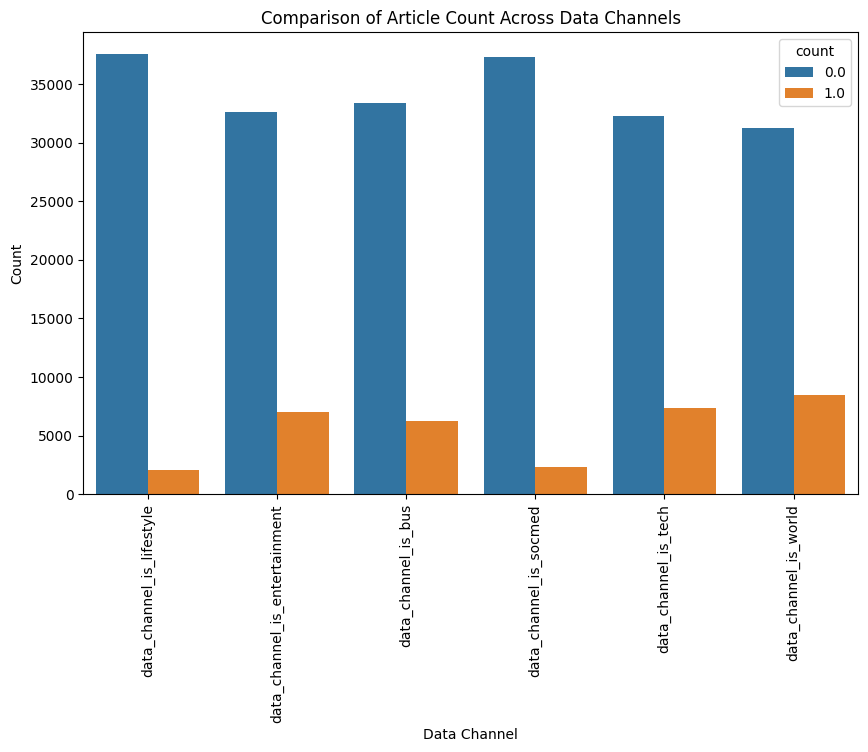

In [ ]:
# Plot grouped countplot
plt.figure(figsize=(10, 6))
sns.countplot(data=df_melted_channels, x='data_channel', hue='count')
plt.title('Comparison of Article Count Across Data Channels')
plt.xlabel('Data Channel')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

- The distribution across data channels shows most articles concentrated in world news, entertainment, business, and technology channels.
- Categories like lifestyle and social media show relatively fewer articles.

In [ ]:
# Select the relevant columns for days of the week
days_columns = article_data[['weekday_is_monday', 'weekday_is_tuesday', 'weekday_is_wednesday',
                   'weekday_is_thursday', 'weekday_is_friday',
                   'is_weekend']]
# Reshape the data into a long format
df_melted_days = pd.melt(days_columns, var_name='day_of_week', value_name='count')
df_melted_days

,day_of_week,count
0,weekday_is_monday,1.0
1,weekday_is_monday,1.0
2,weekday_is_monday,1.0
3,weekday_is_monday,1.0
4,weekday_is_monday,1.0
...,...,...
237859,is_weekend,0.0
237860,is_weekend,0.0
237861,is_weekend,0.0
237862,is_weekend,0.0


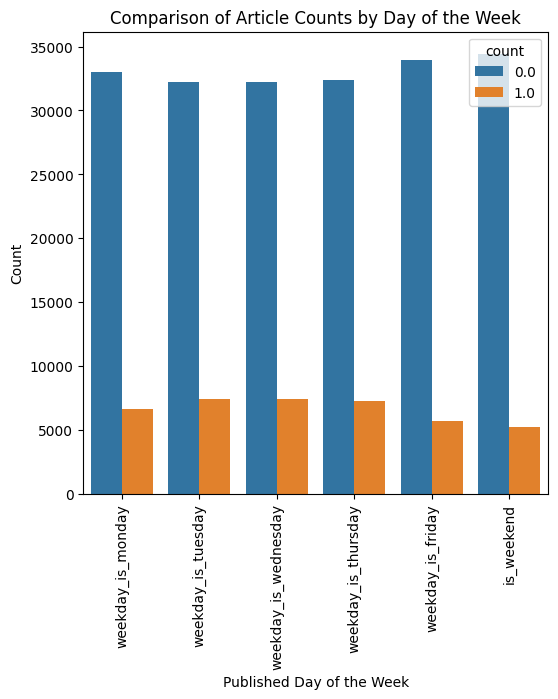

In [ ]:
# Plot using a grouped countplot
plt.figure(figsize=(6,6))
ax = sns.countplot(data=df_melted_days, x='day_of_week', hue='count')
plt.title('Comparison of Article Counts by Day of the Week')
plt.xlabel('Published Day of the Week')
plt.xticks(rotation=90)
plt.ylabel('Count')

plt.show()


- The bar chart compares article counts published on weekdays versus weekends. It shows that significantly more articles are published on weekdays compared to weekends, with a relatively consistent distribution across all weekdays.

In [ ]:



import matplotlib.pyplot as plt

# Function to calculate and display statistics for a given column in binary_data
def calculate_statistics(binary_data, column):
    mean_value = binary_data[column].mean()
    max_value = binary_data[column].max()
    std_dev_value = binary_data[column].std()
    mode_value = binary_data[column].mode()[0]  # Getting the first mode if multiple modes exist
    median_value = binary_data[column].median()

    print(f"Statistics for '{column}':")
    print(f"Mean: {mean_value:.2f}")
    print(f"Max: {max_value:.2f}")
    print(f"Standard Deviation: {std_dev_value:.2f}")
    print(f"Mode: {mode_value:.2f}")
    print(f"Median: {median_value:.2f}")
    print("-" * 50)

# Function to plot bar chart and analyze the column in binary_data
def plot_and_analyze_column(binary_data, column):
    # Plotting Bar Chart
    plt.figure(figsize=(10, 6))
    binary_data[column].value_counts().plot(kind='bar', color='skyblue')
    plt.title(f'Bar Chart of {column}')
    plt.xlabel('Category (0 or 1)')
    plt.ylabel('Frequency')
    plt.xticks(rotation=0)
    plt.show()

    # Calculate and display statistics
    calculate_statistics(binary_data, column)







This code defines two functions: calculate_statistics() computes and prints the mean, max, standard deviation, mode, and median of a binary column, while plot_and_analyze_column() creates a bar chart of the column's value distribution and calls calculate_statistics() to display those stats.

- The DataFrame `article_data` initially contains 39644 rows and 61 columns.


   Univarient analysis:

2.2 Numerical  Variables

On this next step, we are performing univariate analysis to visualize the distribution and key statistics of the numerical column.


Numerical Analysis

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_histogram_and_boxplot_for_column(data, column):
    """
    This function will plot a histogram and boxplot for a single column.
    It will also print the column's statistical properties: mean, median, std deviation, mode, and null values.
    """
    # Ensure column exists in the data
    if column not in data.columns:
        print(f"Column '{column}' not found in the data.")
        return

    # Calculate statistics
    mean = data[column].mean()
    median = data[column].median()
    std_dev = data[column].std()
    mode = data[column].mode()[0]
    null_values = data[column].isnull().sum()

    # Print statistics
    print(f"Statistics for '{column}':")
    print(f"Mean: {mean}")
    print(f"Median: {median}")
    print(f"Standard Deviation: {std_dev}")
    print(f"Mode: {mode}")
    print(f"Null Values: {null_values}")
    print("-" * 50)

    # Plotting
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Boxplot
    sns.boxplot(y=data[column], ax=axes[0], color='skyblue')
    axes[0].set_title(f'Boxplot of {column}')

    # Distribution Plot
    sns.histplot(data[column], bins=30, kde=True, ax=axes[1], color='salmon')
    axes[1].set_title(f'Distribution of {column}')

    # Add statistics as text on the distribution plot
    stats_text = (f'Mean: {mean:.2f}\n'
                  f'Median: {median:.2f}\n'
                  f'Standard Deviation: {std_dev:.2f}\n'
                  f'Mode: {mode}\n'
                  f'Null Values: {null_values}\n'
                )

    axes[1].text(0.95, 0.95, stats_text, transform=axes[1].transAxes,
                 verticalalignment='top', horizontalalignment='right',
                 bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.5', alpha=0.7))

    plt.tight_layout()
    plt.show()


The code defines a function that calculates and prints key statistics (mean, median, std deviation, mode, null values) for a given column in the dataset. It then generates a boxplot and a histogram

### n_tokens_title:Number of words in the article's title

Statistics for 'n_tokens_title':
Mean: 10.398748864897588
Median: 10.0
Standard Deviation: 2.11403680830354
Mode: 10.0
Null Values: 0
--------------------------------------------------


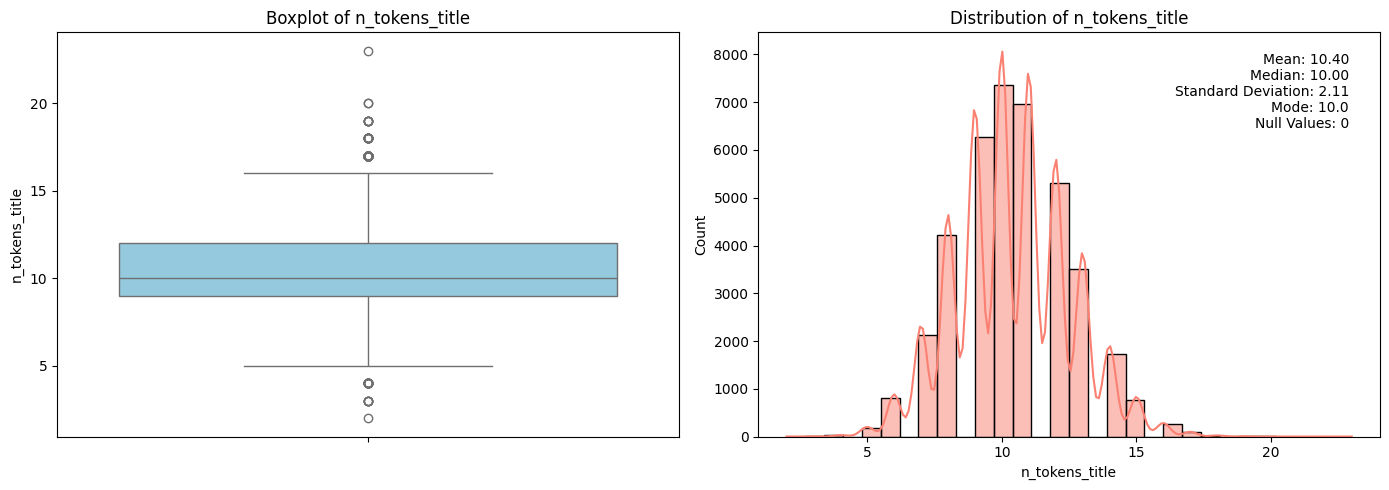

In [ ]:
plot_histogram_and_boxplot_for_column(numeric_data, 'n_tokens_title')

Number of words in the article's title  - The "n_tokens_title"  data is mostly around 10 words, with some variation and a few outliers. Most titles have about 10 words, but some are much longer or shorter. The box plot shows where the middle 50% of the titles fall and highlights the outliers

### n_tokens_content

Number of words in the article's content, showing how much information the article provides.

Statistics for 'n_unique_tokens':
Mean: 0.5482157168486131
Median: 0.5392255481715
Standard Deviation: 3.5207083312411243
Mode: 0.0
Null Values: 0
--------------------------------------------------


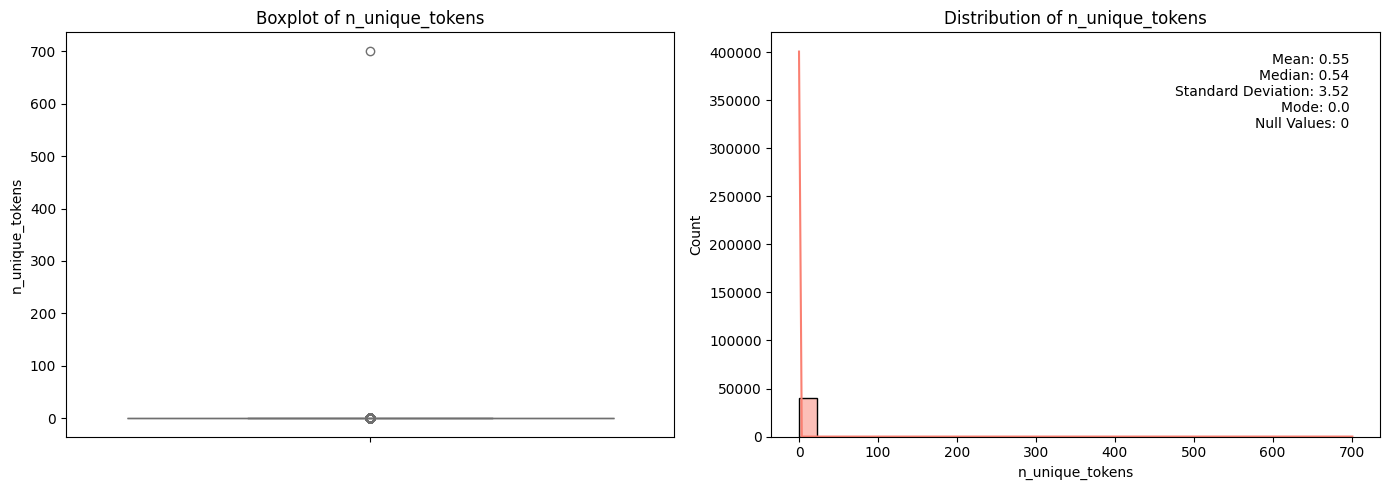

In [ ]:
plot_histogram_and_boxplot_for_column(numeric_data, 'n_unique_tokens')

- The majority of articles have a relatively low word count, with a few articles having significantly higher word counts. This indicates that most articles are shorter, while a few longer articles create a tail on the right side of the distribution.

### n_non_stop_words

Proportion of meaningful words (non-stop words) in the article, which could make it more engaging.

Statistics for 'n_non_stop_words':
Mean: 0.9964685654578609
Median: 0.999999995968
Standard Deviation: 5.231230945150023
Mode: 0.0
Null Values: 0
--------------------------------------------------


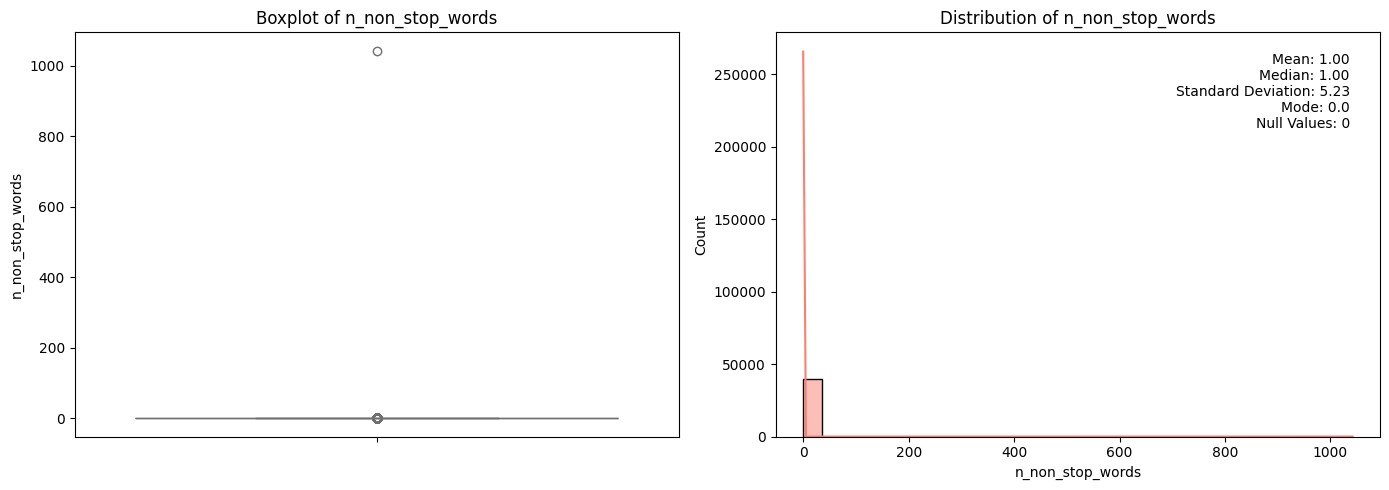

In [ ]:
plot_histogram_and_boxplot_for_column(numeric_data, 'n_non_stop_words')

- The "n_non_stop_words" data is right-skewed, with most articles having a low proportion of non-stop words and a few articles showing much higher values, as reflected by a high standard deviation and a wide range.


#### n_non_stop_unique_tokens

Proportion of unique non-stop words, reflecting the richness of the article's content.

Statistics for 'n_non_stop_unique_tokens':
Mean: 0.6891753940079294
Median: 0.6904761882745001
Standard Deviation: 3.2648163548136893
Mode: 0.0
Null Values: 0
--------------------------------------------------


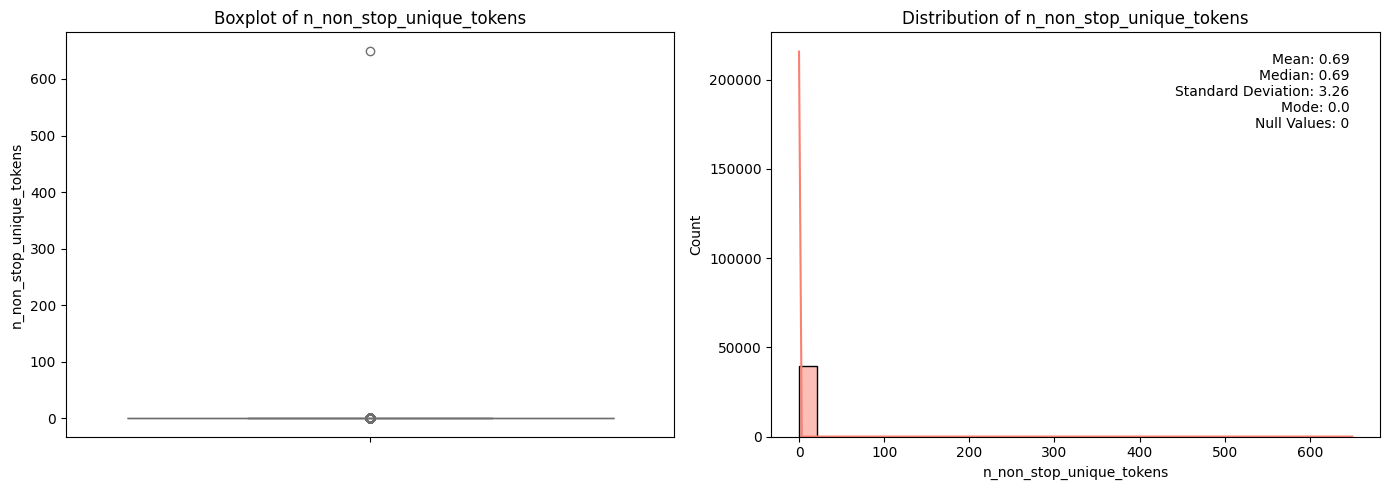

In [ ]:
plot_histogram_and_boxplot_for_column(numeric_data, 'n_non_stop_unique_tokens')

- The distribution of n_non_stop_unique_tokens(Proportion of unique non-stop words) is highly right-skewed, with most observations clustering around 0 to 100.

### num_hrefs

Number of hyperlinks in the article, indicating how well-connected it is to external sources.

Statistics for 'num_hrefs':
Mean: 10.883689839572192
Median: 8.0
Standard Deviation: 11.332017376010986
Mode: 4.0
Null Values: 0
--------------------------------------------------


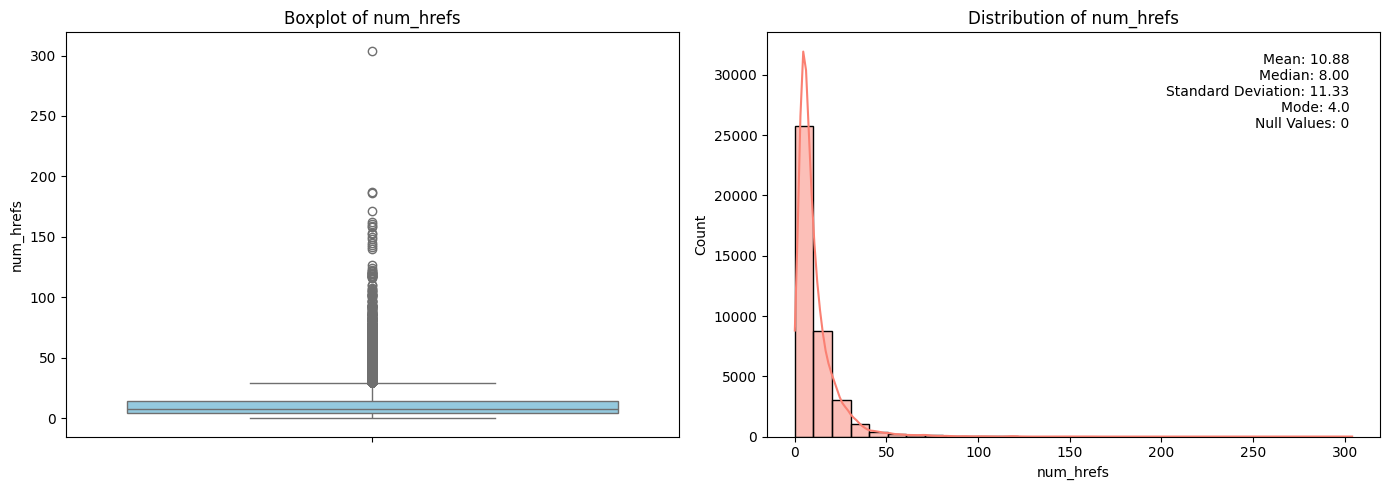

In [ ]:
plot_histogram_and_boxplot_for_column(numeric_data, 'num_hrefs')

- The distribution of the num_hrefs(Number of hyperlinks in the article ) variable appears to be right-skewed, with most observations falling between 0 and 20. The median is around a low value, with a few extreme outliers reaching up to 300.


### num_self_hrefs

Number of internal links in the article, indicating how much it promotes other articles on the same site

Statistics for 'num_self_hrefs':
Mean: 3.2936383815962063
Median: 3.0
Standard Deviation: 3.8551411453741316
Mode: 2.0
Null Values: 0
--------------------------------------------------


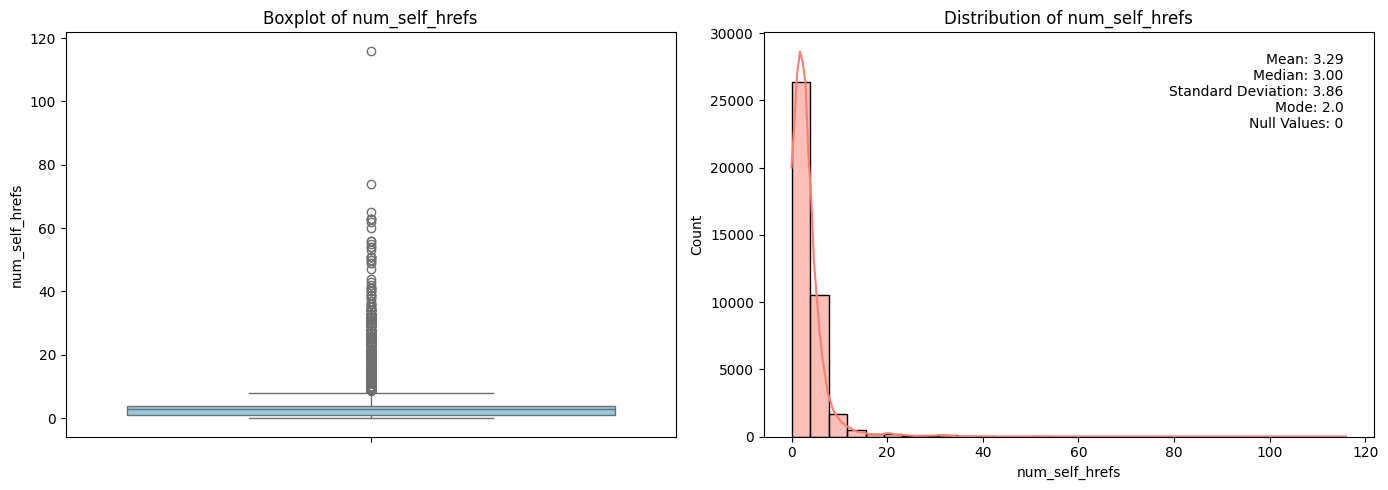

In [ ]:
plot_histogram_and_boxplot_for_column(numeric_data, 'num_self_hrefs')

- The distribution of num_self_hrefs(Number of self-referencing links (links to other articles on the same website)) is heavily right-skewed, with most values concentrated below 10. The median is around 3, while the range extends from 0 to about 120, indicating the presence of outliers.

#### num_imgs

Number of images in the article, which can enhance its visual appeal.

Statistics for 'num_imgs':
Mean: 4.544142871556856
Median: 1.0
Standard Deviation: 8.309433519603113
Mode: 1.0
Null Values: 0
--------------------------------------------------


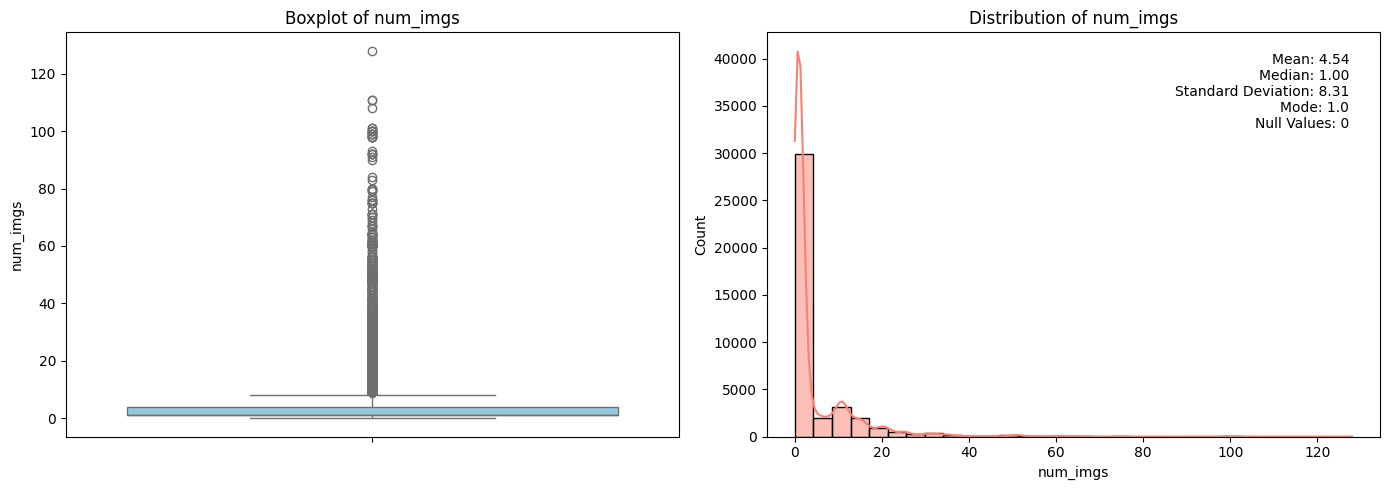

In [ ]:
plot_histogram_and_boxplot_for_column(numeric_data, 'num_imgs')

- The distribution of the num_imgs(Number of images in the article) variable is highly right-skewed, with most observations concentrated between 0 and 10. The median is low, with several outliers extending beyond 100

### num_videos

Number of videos in the article, which may increase reader engagement and sharing.

Statistics for 'num_videos':
Mean: 1.2498738775098375
Median: 0.0
Standard Deviation: 4.107855086225022
Mode: 0.0
Null Values: 0
--------------------------------------------------


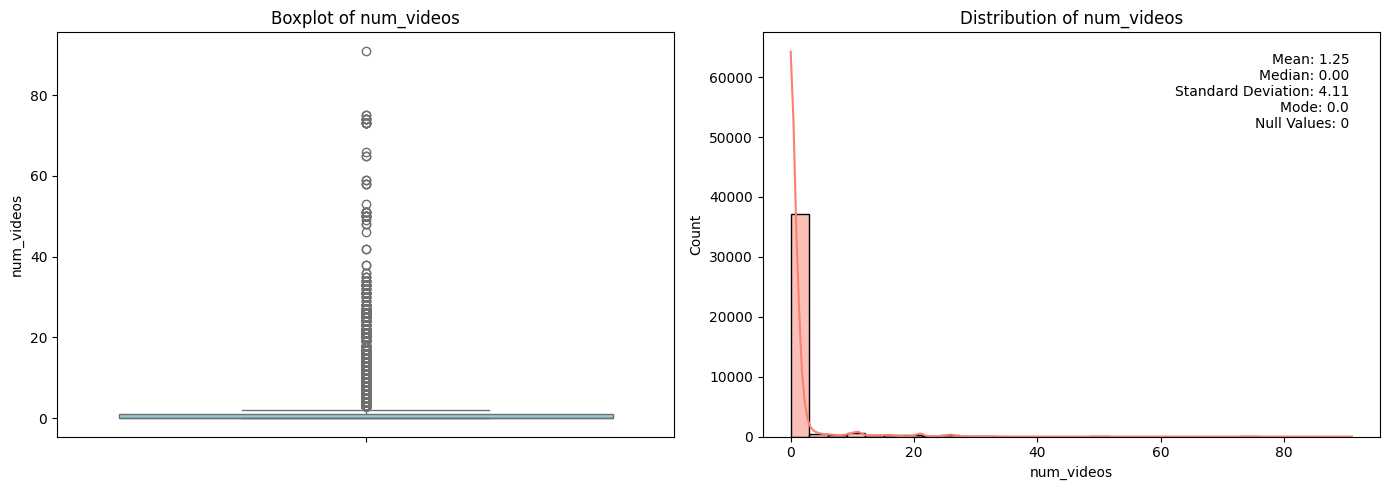

In [ ]:
plot_histogram_and_boxplot_for_column(numeric_data, 'num_videos')

- The distribution of num_videos is highly right-skewed, with most values clustered below 5. The mean is about 1.25, and the presence of outliers extends the range up to over 80.

##  average_token_length

Average length of the words used in the article, possibly indicating content complexity.

Statistics for 'average_token_length':
Mean: 4.548239318341828
Median: 4.664082178605
Standard Deviation: 0.8444055651953591
Mode: 0.0
Null Values: 0
--------------------------------------------------


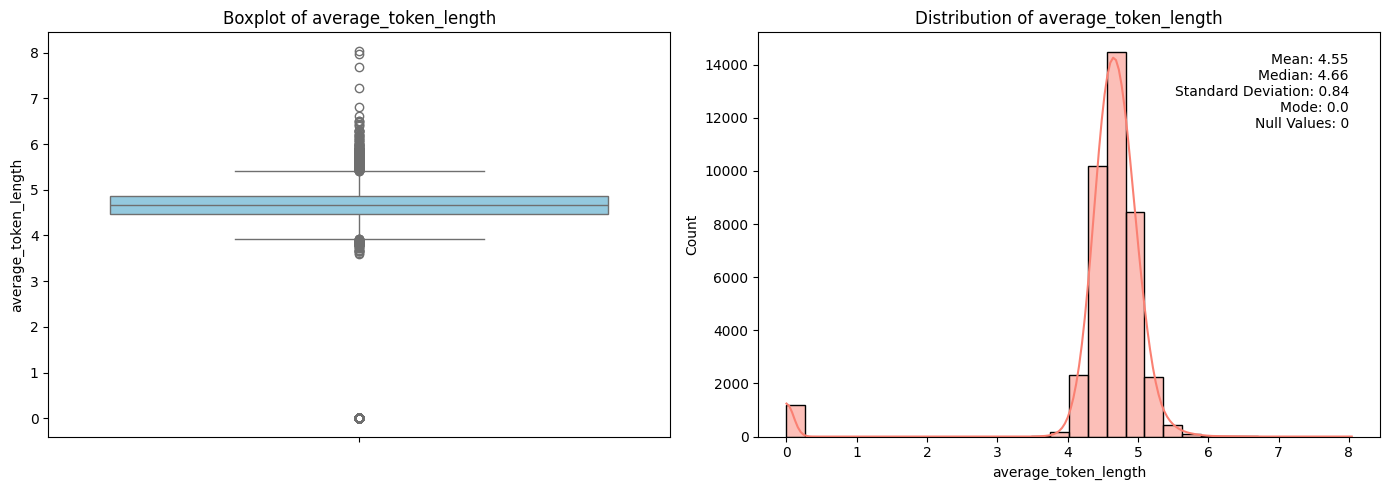

In [ ]:
plot_histogram_and_boxplot_for_column(numeric_data, 'average_token_length')

- The distribution of average token length is right-skewed, with most observations clustered around 4 to 5.
The median token length appears to be around 4 units, with several outliers extending beyond 6 units.

### num_keywords

Number of keywords assigned to the article, affecting search engine visibility and traffic.

Statistics for 'num_keywords':
Mean: 7.223766522046211
Median: 7.0
Standard Deviation: 1.9091303859704352
Mode: 7.0
Null Values: 0
--------------------------------------------------


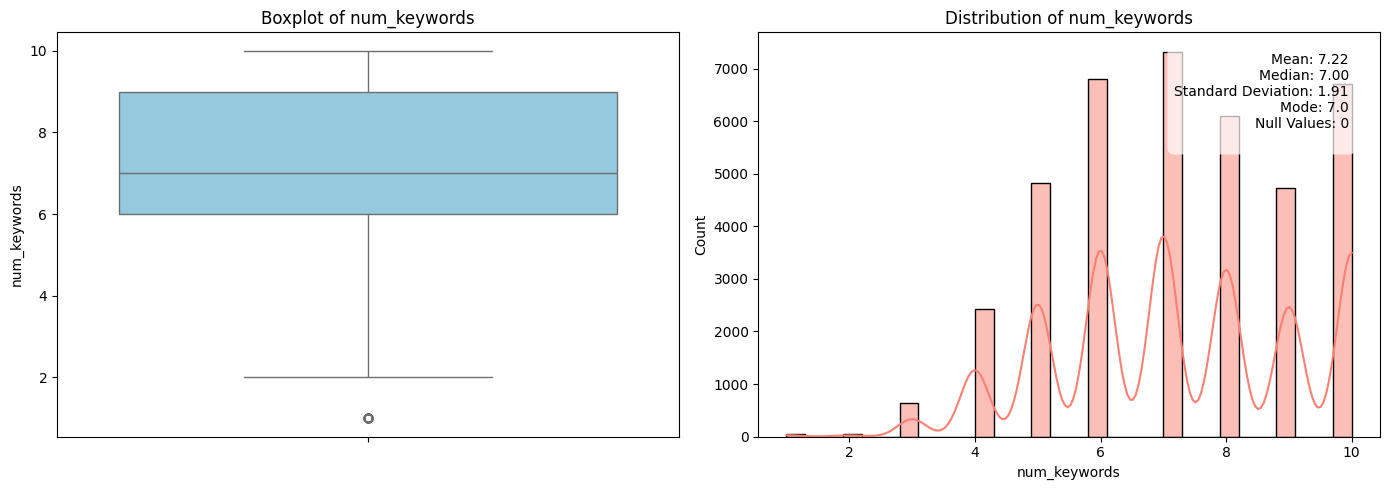

In [ ]:
plot_histogram_and_boxplot_for_column(numeric_data, 'num_keywords')

- The distribution of the number of keywords is approximately uniform, with most values between 6 and 9. The median number of keywords is around 7, with a few lower outliers near 2.

#### kw_min_min

Minimum number of shares for the least popular keyword.

Statistics for 'kw_min_min':
Mean: 26.10680052466956
Median: -1.0
Standard Deviation: 69.6332151214891
Mode: -1.0
Null Values: 0
--------------------------------------------------


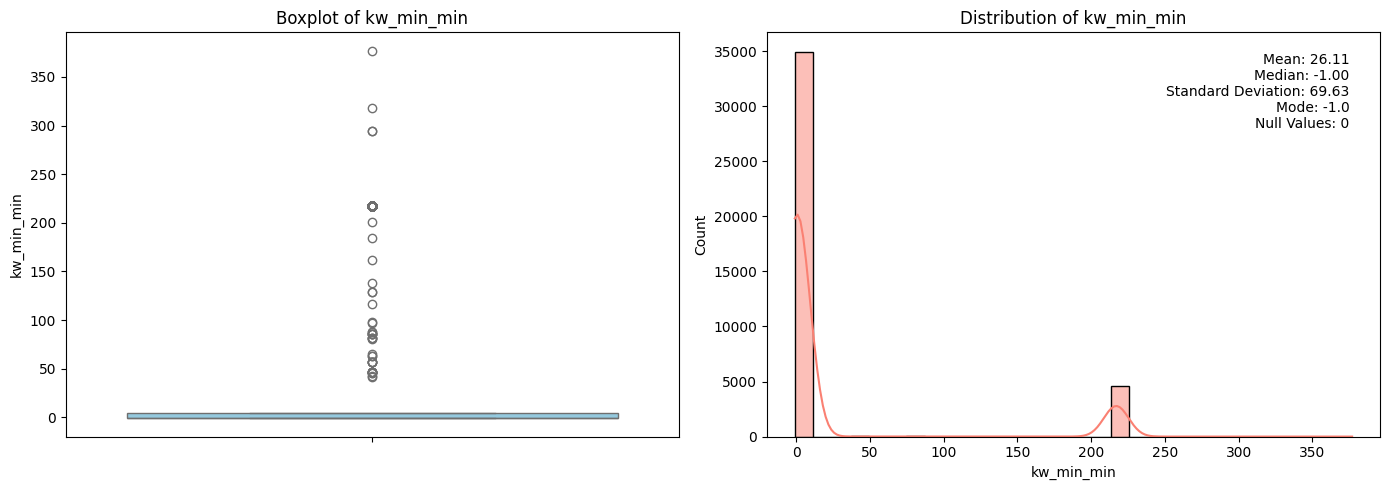

In [ ]:
plot_histogram_and_boxplot_for_column(numeric_data, 'kw_min_min')

- For kw_min_min, the highest values lie between 0 and 10.

### kw_max_min

Maximum number of shares for the least popular keyword.

Statistics for 'kw_max_min':
Mean: 1153.9516822217738
Median: 660.0
Standard Deviation: 3857.9908765299933
Mode: 1100.0
Null Values: 0
--------------------------------------------------


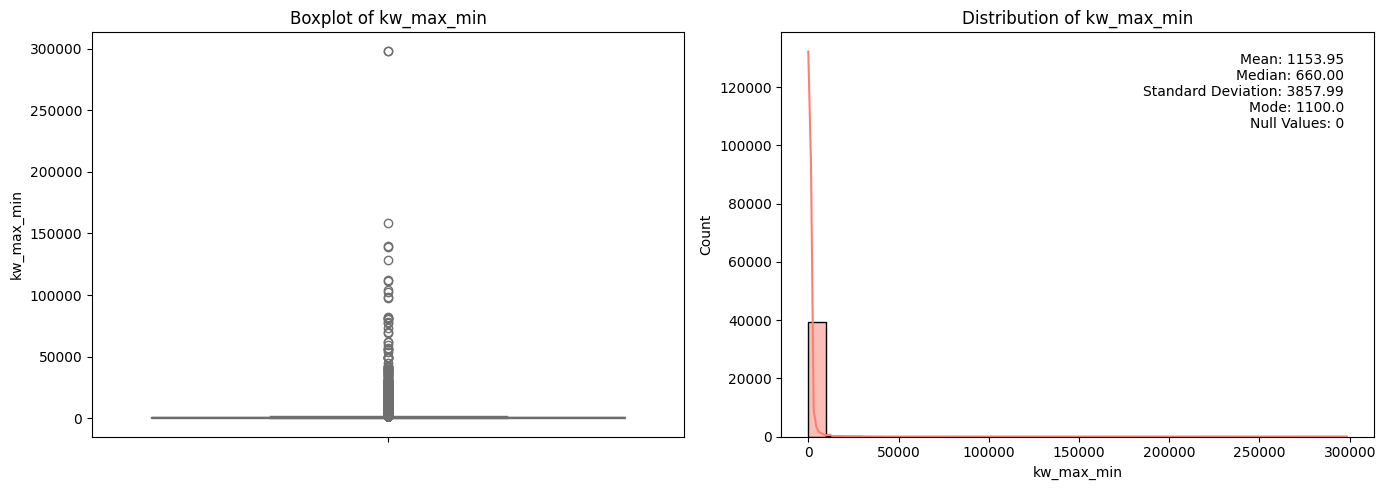

In [ ]:
plot_histogram_and_boxplot_for_column(numeric_data, 'kw_max_min')

- For kw_max_min, most values fall below 500. The box plot shows a median around 1000, with values ranging from 0 to approximately 3500, indicating a wide spread of data.

### kw_avg_min

Average number of shares for the least popular keyword.

Statistics for 'kw_avg_min':
Mean: 312.36696679715334
Median: 235.5
Standard Deviation: 620.7838873138074
Mode: -1.0
Null Values: 0
--------------------------------------------------


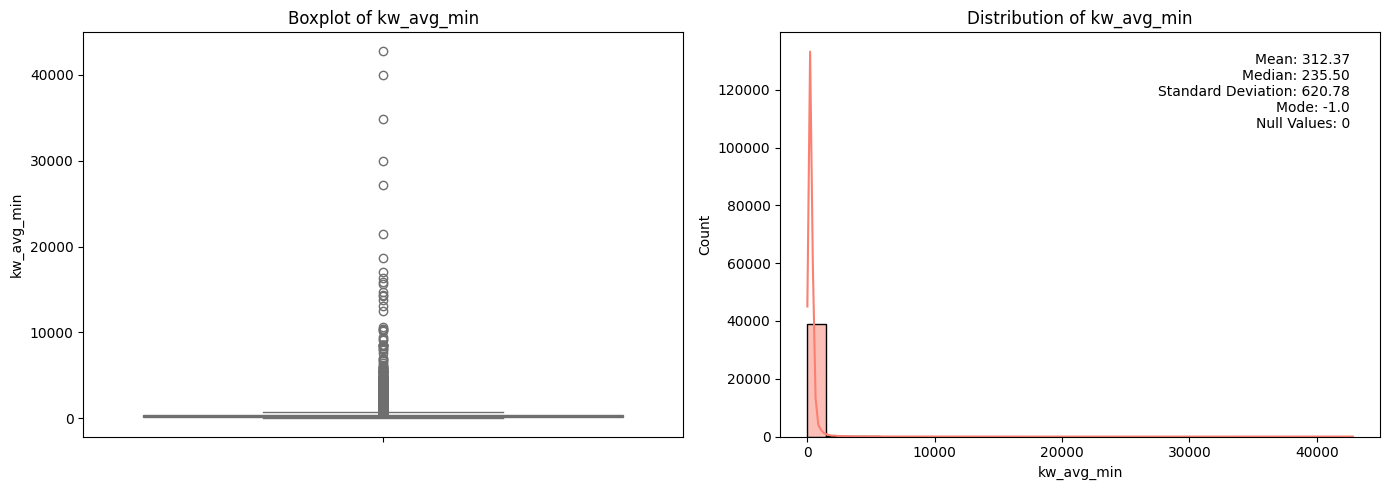

In [ ]:
plot_histogram_and_boxplot_for_column(numeric_data, 'kw_avg_min')

- The distribution is clearly right‐skewed, with a median of 230 and a wide spread.

#### kw_min_max

Minimum number of shares for the most popular keyword.

Statistics for 'kw_min_max':
Mean: 13612.35410150338
Median: 1400.0
Standard Deviation: 57986.02935737641
Mode: 0.0
Null Values: 0
--------------------------------------------------


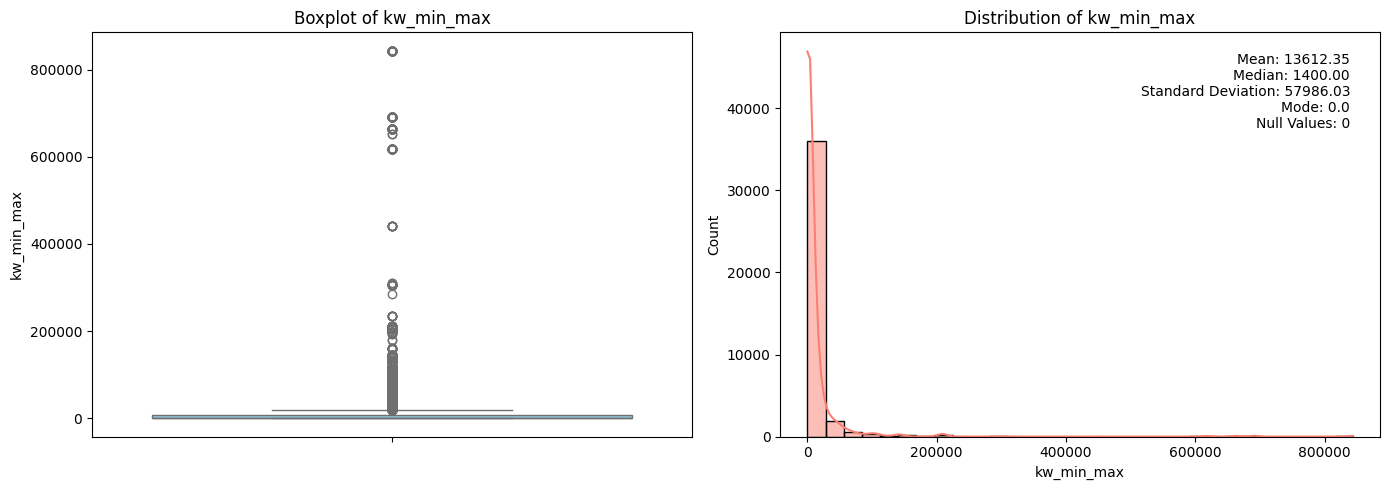

In [ ]:
plot_histogram_and_boxplot_for_column(numeric_data, 'kw_min_max')

- The distribution of kw_min_max(average number of shares)is right-skewed, with most observations falling below 10,000 units.
The box plot shows a median value of around 1,500 units, with many extreme outliers reaching above 40,000 units.

### kw_max_max

Maximum number of shares for the most popular keyword.

Statistics for 'kw_max_max':
Mean: 752324.0666935728
Median: 843300.0
Standard Deviation: 214502.12957278264
Mode: 843300.0
Null Values: 0
--------------------------------------------------


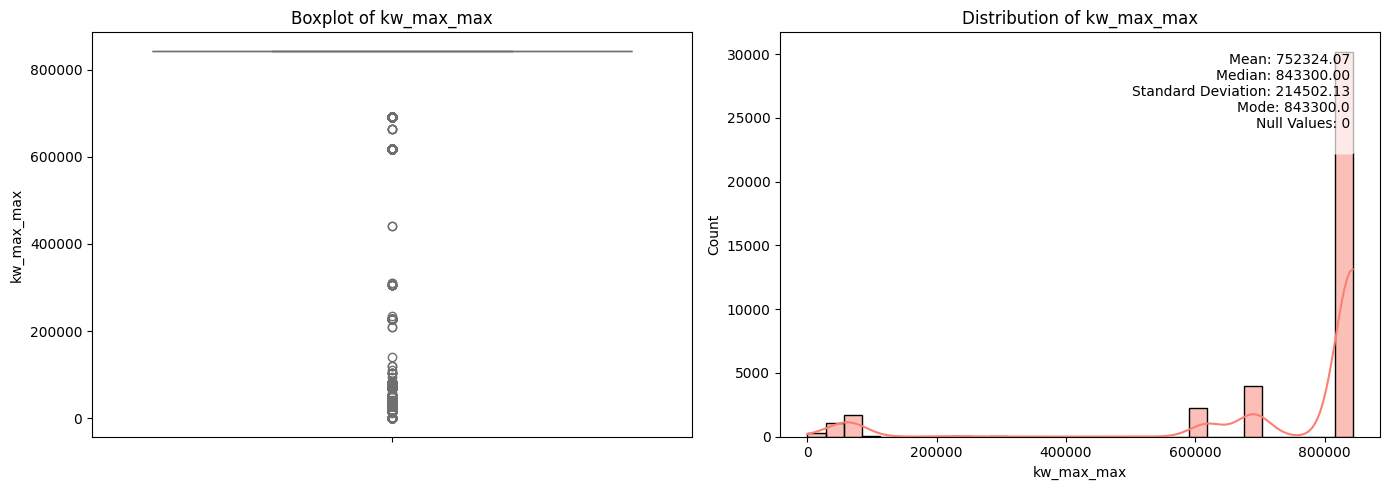

In [ ]:
plot_histogram_and_boxplot_for_column(numeric_data, 'kw_max_max')

- The distribution shows it is widely spread but the distribution is not normal , with a median of 840000

### kw_avg_max

Average number of shares for the most popular keyword.

Statistics for 'kw_avg_max':
Mean: 259281.93808264728
Median: 244572.22222250002
Standard Deviation: 135102.2472847749
Mode: 0.0
Null Values: 0
--------------------------------------------------


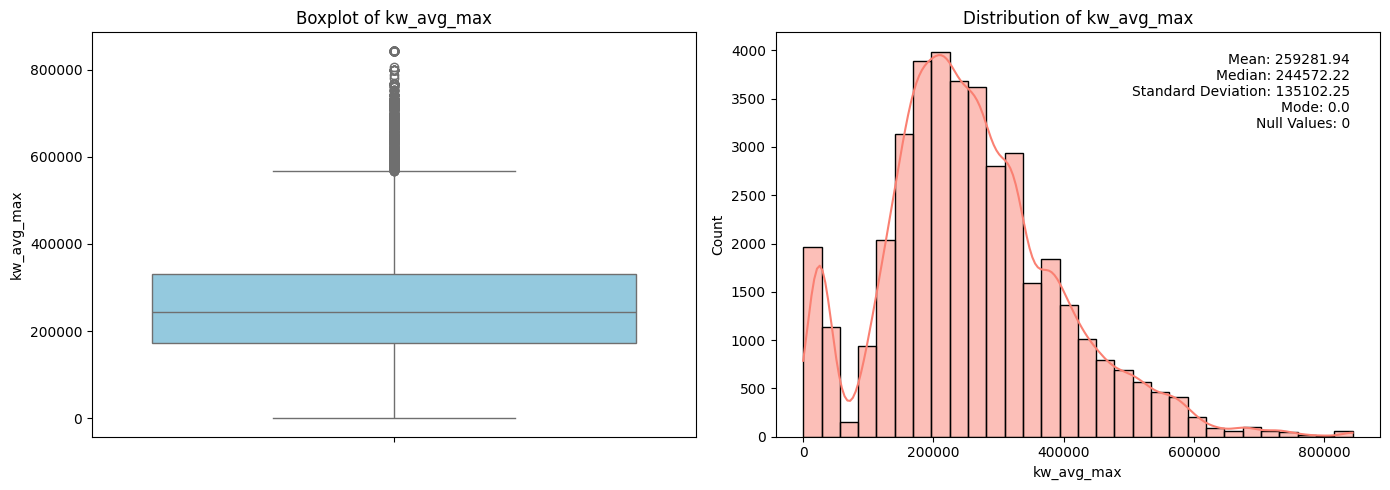

In [ ]:
plot_histogram_and_boxplot_for_column(numeric_data, 'kw_avg_max')

- The distribution is right‐skewed; most of the data points lie between 0 and 600,000.

#### kw_min_avg

Minimum number of shares for all keywords.

Statistics for 'kw_min_avg':
Mean: 1117.1466099698362
Median: 1023.6356107649999
Standard Deviation: 1137.4569507729946
Mode: 0.0
Null Values: 0
--------------------------------------------------


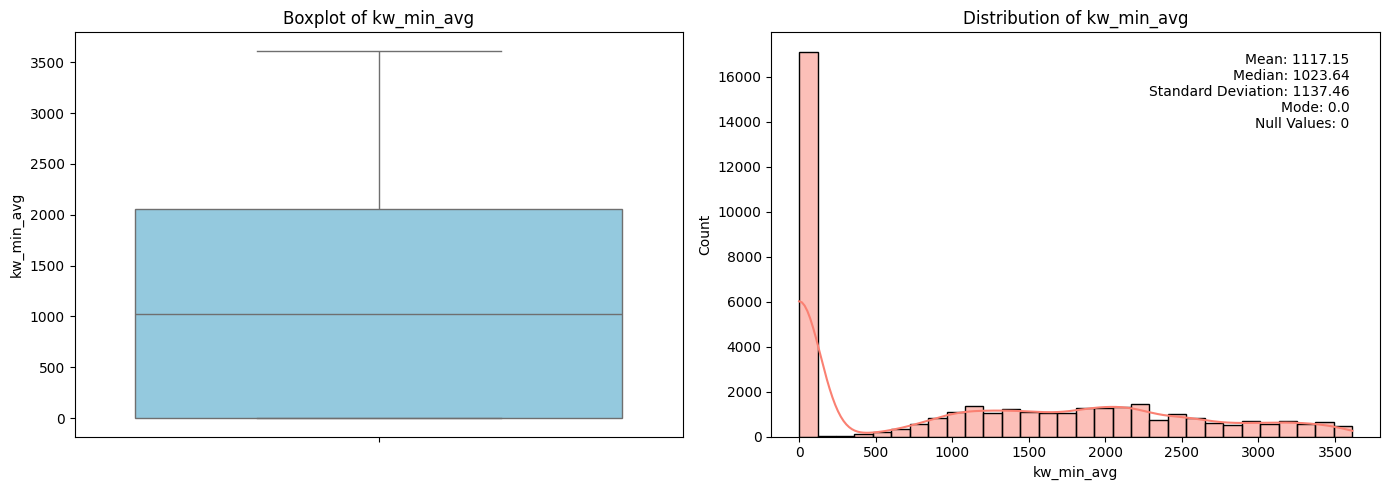

In [ ]:
plot_histogram_and_boxplot_for_column(numeric_data, 'kw_min_avg')

- The kw_min_avg variable is right-skewed, with most values falling below 500.
The box plot shows a median around 1000, with values ranging from 0 to approximately 3500, indicating a wide spread of data.

### kw_max_avg

Maximum number of shares for all keywords.

Statistics for 'kw_max_avg':
Mean: 5657.211151064957
Median: 4355.68883632
Standard Deviation: 6098.871956751086
Mode: 0.0
Null Values: 0
--------------------------------------------------


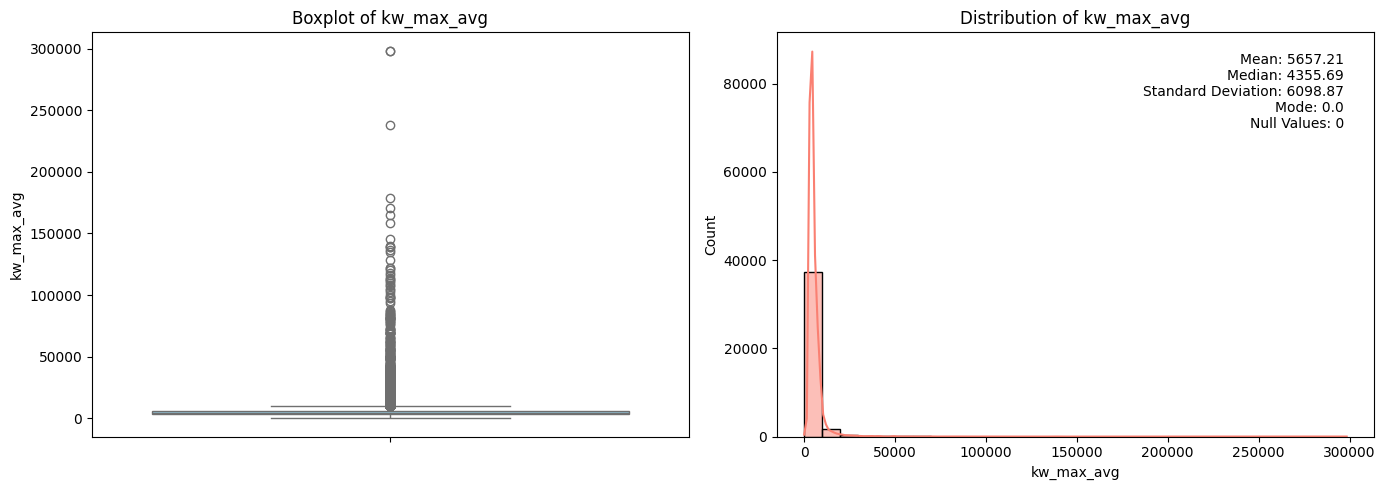

In [ ]:
plot_histogram_and_boxplot_for_column(numeric_data, 'kw_max_avg')

The distribution is right‐skewed, and the data is spread all over.

#### kw_avg_avg

Average number of shares for all keywords.


Statistics for 'kw_avg_avg':
Mean: 3135.8586389465236
Median: 2870.07487821
Standard Deviation: 1318.1503970937204
Mode: 0.0
Null Values: 0
--------------------------------------------------


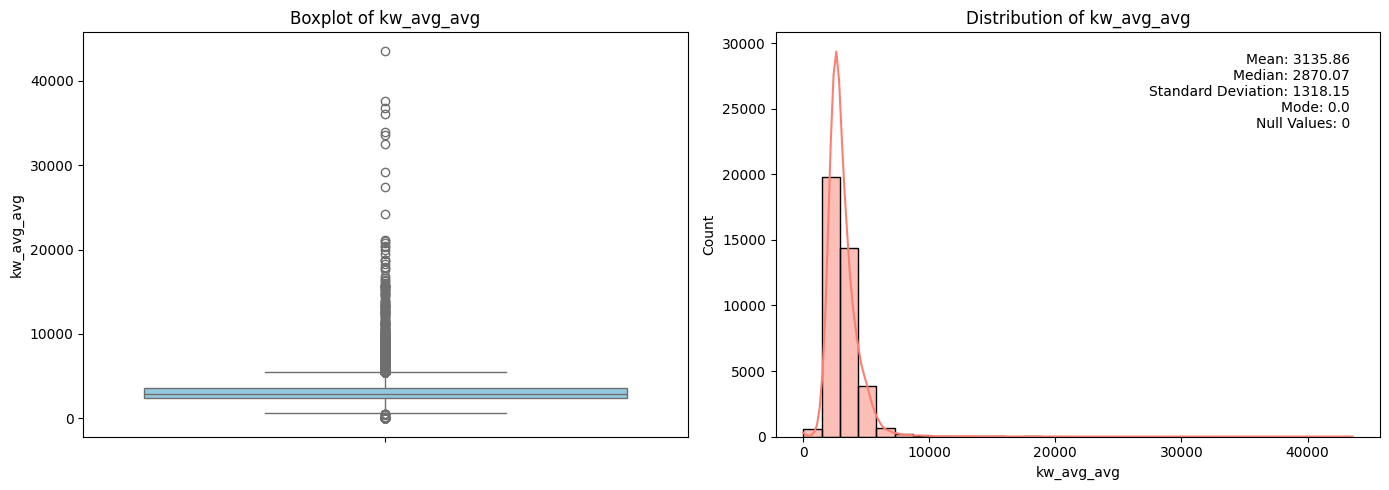

In [ ]:
plot_histogram_and_boxplot_for_column(numeric_data, 'kw_avg_avg')

The distribution of kw_avg_avg(average number of shares)is right-skewed, with most observations falling below 10,000 units.
The box plot shows a median value of around 1,500 units, with many extreme outliers reaching above 40,000 units.

#### self_reference_min_shares

Minimum shares for articles referenced within the article.

Statistics for 'self_reference_min_shares':
Mean: 3998.7553955201292
Median: 1200.0
Standard Deviation: 19738.67051625999
Mode: 0.0
Null Values: 0
--------------------------------------------------


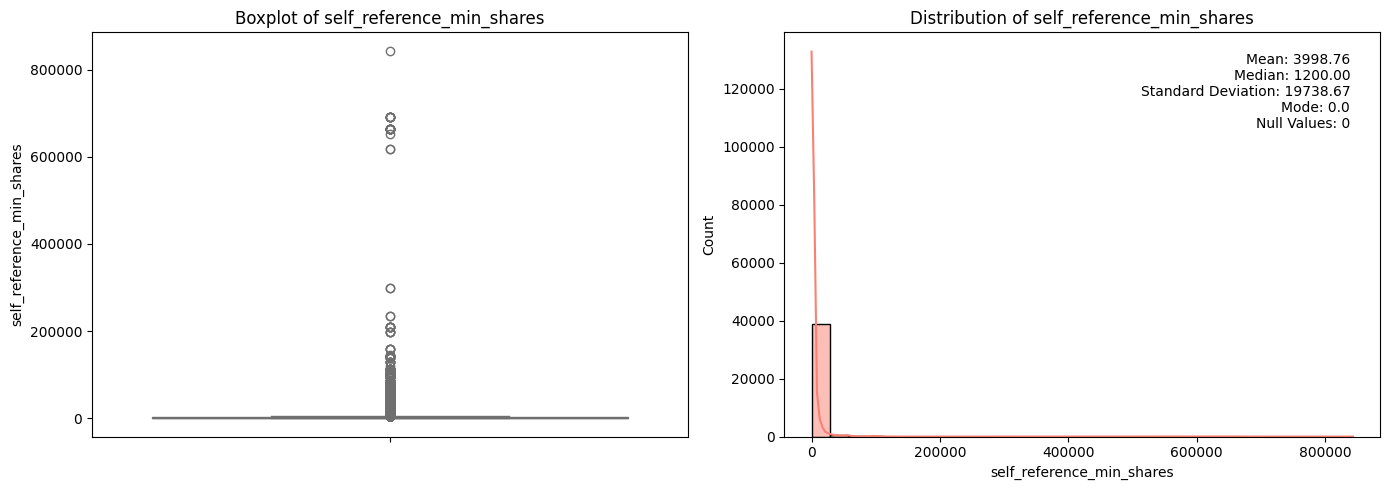

In [ ]:
plot_histogram_and_boxplot_for_column(numeric_data, 'self_reference_min_shares')

The distribution is right‐skewed, with most of the data lying to the right of the median.

#### self_reference_max_shares

Maximum shares for articles referenced within the article.

Statistics for 'self_reference_max_shares':
Mean: 10329.212661941277
Median: 2800.0
Standard Deviation: 41027.57661292357
Mode: 0.0
Null Values: 0
--------------------------------------------------


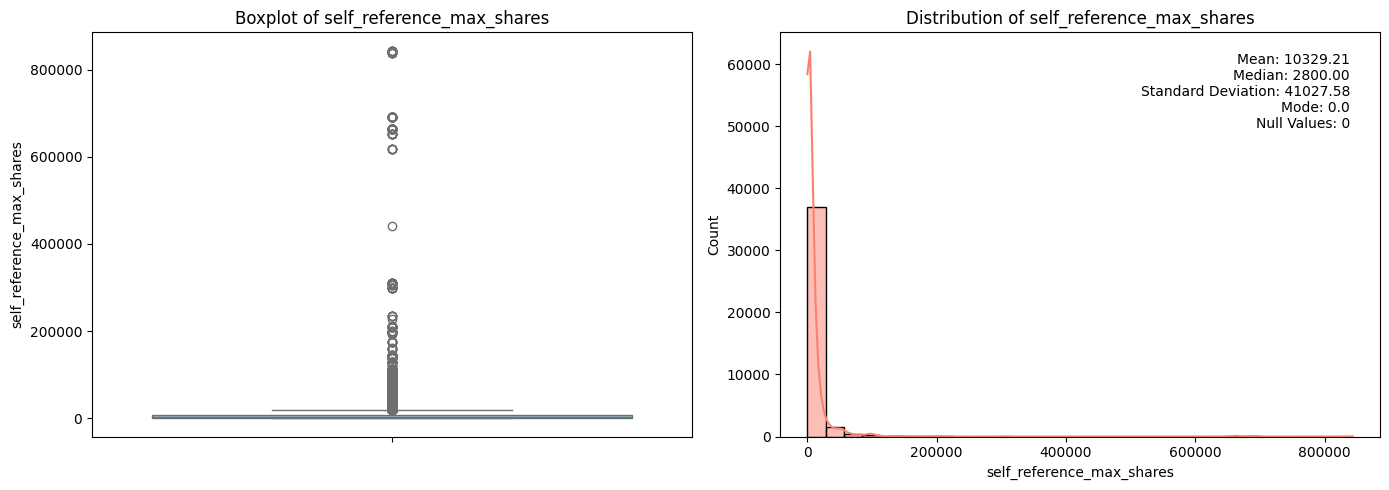

In [ ]:
plot_histogram_and_boxplot_for_column(numeric_data, 'self_reference_max_shares')

The distribution is right‐skewed, with maximum values lying between 0 and 10,000.

#### self_reference_avg_sharess

Average shares of articles that are referenced within the article.

Statistics for 'self_reference_avg_sharess':
Mean: 6401.697579821467
Median: 2200.0
Standard Deviation: 24211.332231313183
Mode: 0.0
Null Values: 0
--------------------------------------------------


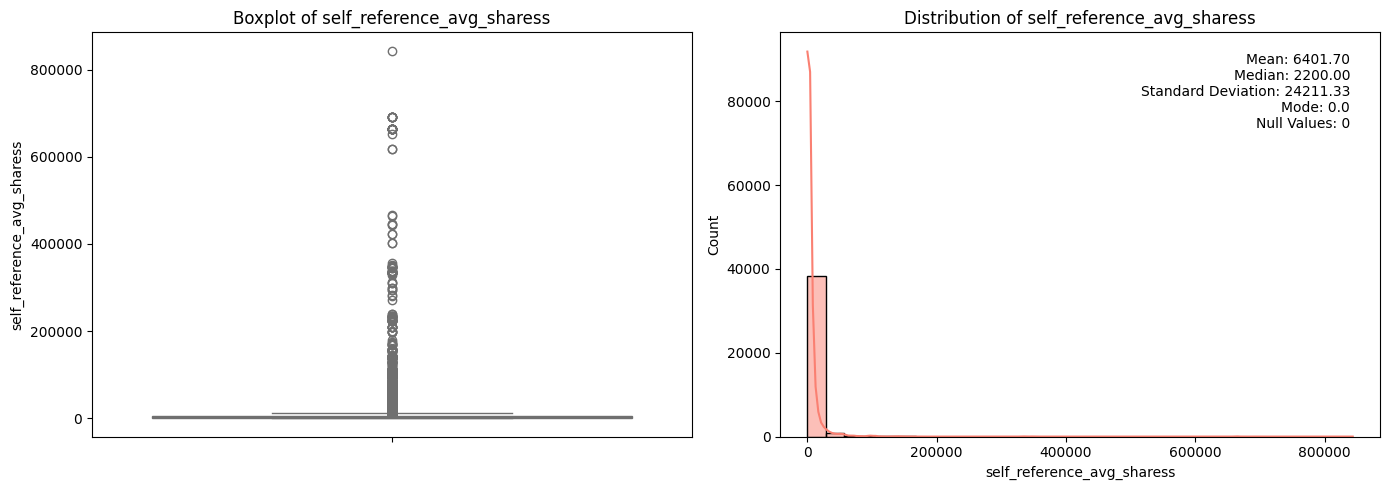

In [ ]:
plot_histogram_and_boxplot_for_column(numeric_data, 'self_reference_avg_sharess')

The distribution is right‐skewed, with the highest values lying between 0 and 10,000.

### LDA_00

The article's similarity to the first topic in the Latent Dirichlet Allocation (LDA) model.

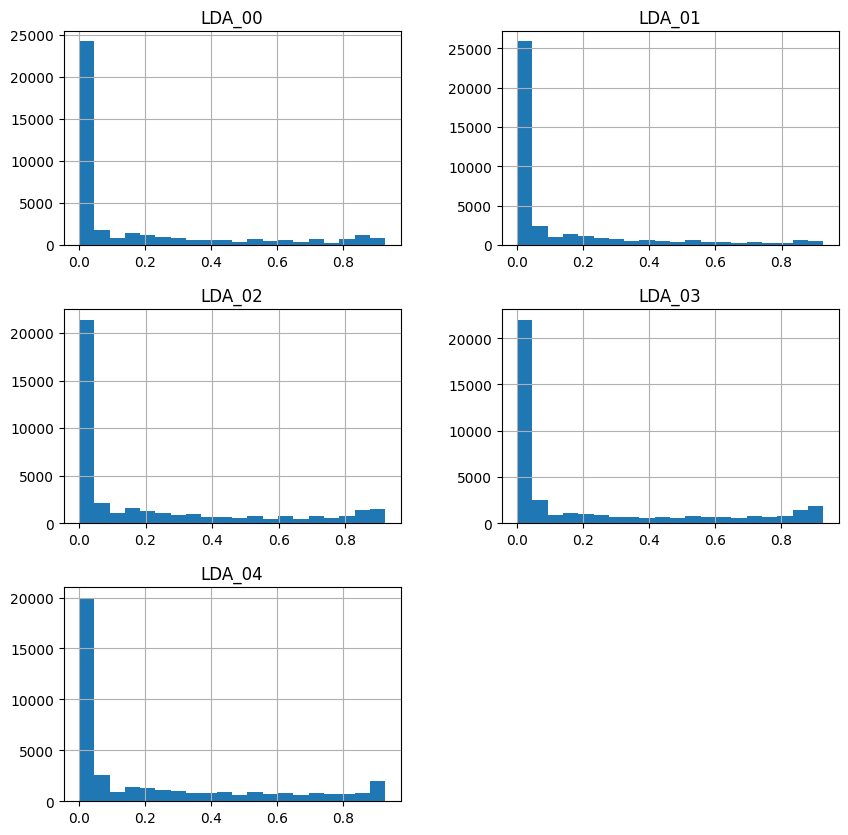

In [ ]:
numeric_data[['LDA_00','LDA_01', 'LDA_02', 'LDA_03', 'LDA_04']].hist(figsize=(10,10), bins=20)
plt.show()

LDA_01
The article's similarity to the second topic in the LDA model.

LDA_02
The article's similarity to the third topic in the LDA model.

LDA_03
The article's similarity to the fourth topic in the LDA model.

LDA_04
The article's similarity to the fifth topic in the LDA model.

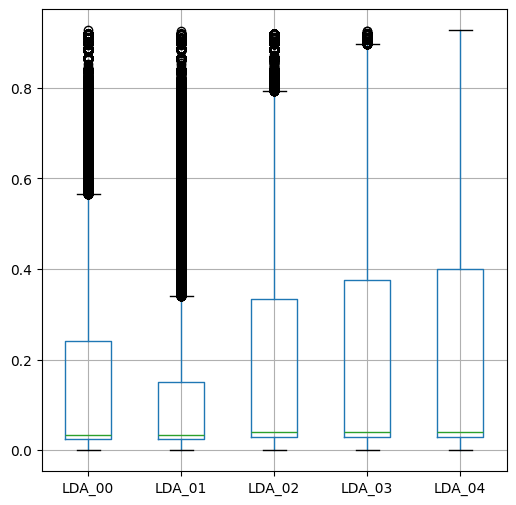

,LDA_00,LDA_01,LDA_02,LDA_03,LDA_04
count,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000
mean,0.184599,0.141256,0.216321,0.223770,0.234029
std,0.262975,0.219707,0.282145,0.295191,0.289183
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.025051,0.025012,0.028571,0.028571,0.028574
50%,0.033387,0.033345,0.040004,0.040001,0.040727
75%,0.240958,0.150831,0.334218,0.375763,0.399986
max,0.926994,0.925947,0.919999,0.926534,0.927191


In [ ]:
numeric_data[['LDA_00','LDA_01', 'LDA_02', 'LDA_03', 'LDA_04']].boxplot(figsize=(6,6))
plt.show()

numeric_data[['LDA_00','LDA_01', 'LDA_02', 'LDA_03', 'LDA_04']].describe()

The box plots for the LDA topics (LDA_00 to LDA_04) show a wide range of distributions, with most median values near zero and significant variation among the upper quartiles.
Each plot indicates the presence of many outliers, particularly in LDA_00, LDA_01, and LDA_02, with values extending above 0.8.

#### global_subjectivity

Overall subjectivity of the article's content (closer to 1 means more subjective, closer to 0 means more objective).


Statistics for 'global_subjectivity':
Mean: 0.443370199550738
Median: 0.4534573473025
Standard Deviation: 0.11668464244606234
Mode: 0.0
Null Values: 0
--------------------------------------------------


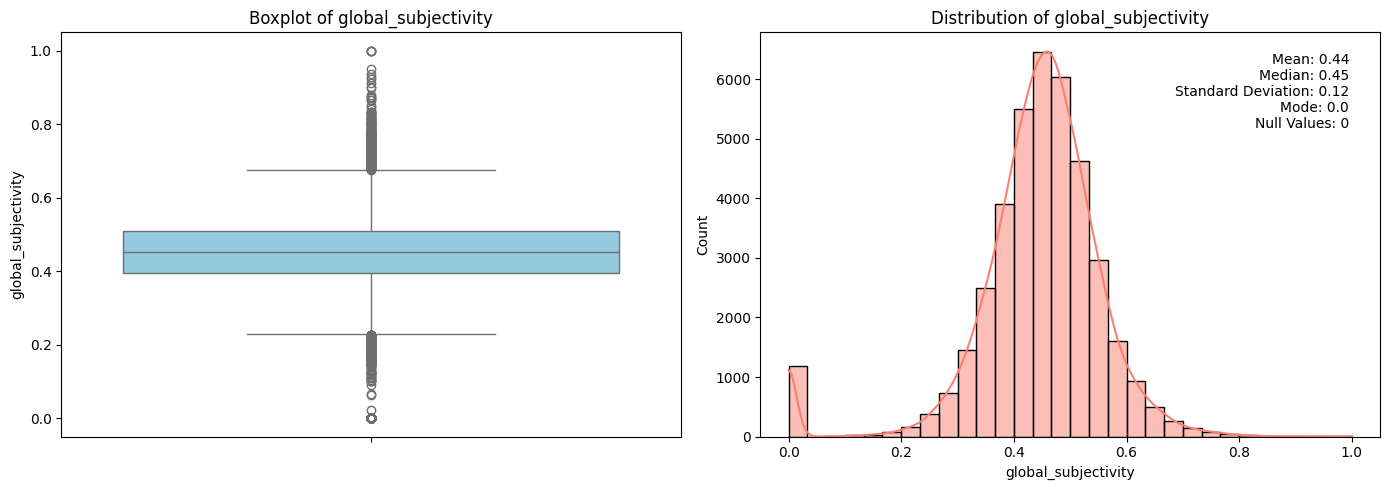

In [ ]:
plot_histogram_and_boxplot_for_column(article_data, 'global_subjectivity')


The distribution of global subjectivity is roughly normal, centered around 0.44. The boxplot shows some outliers on both ends.

#### global_sentiment_polarity

Overall sentiment polarity of the article, indicating whether it is positive or negative.

Statistics for 'global_sentiment_polarity':
Mean: 0.11930926928571745
Median: 0.119116768648
Standard Deviation: 0.09693066125190916
Mode: 0.0
Null Values: 0
--------------------------------------------------


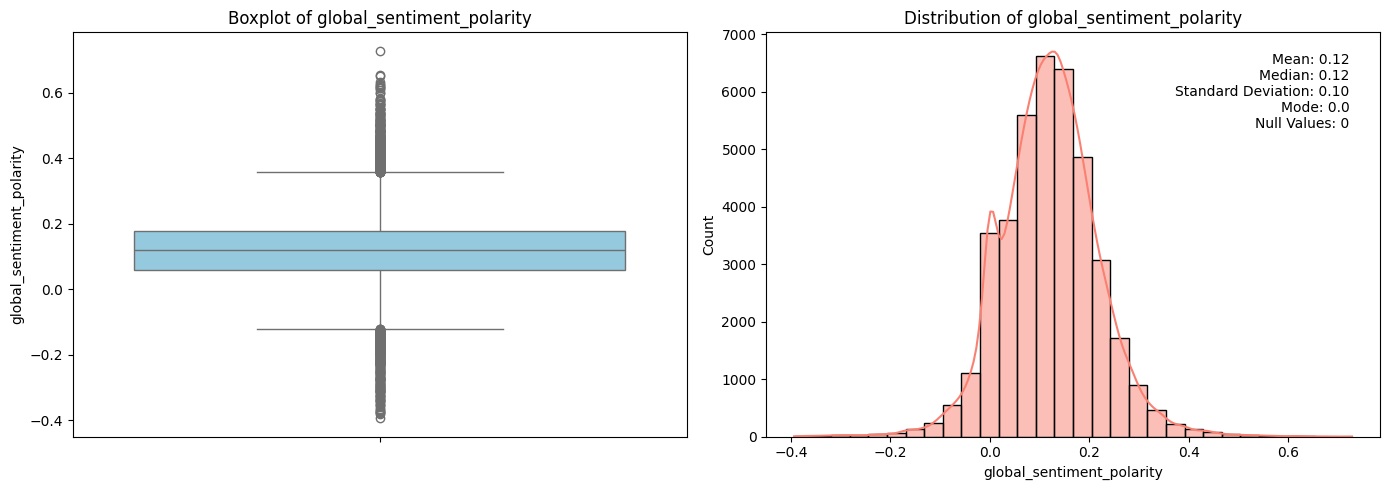

In [ ]:
plot_histogram_and_boxplot_for_column(article_data, 'global_sentiment_polarity')


The variables show varied distributions, with most median values near zero, while some, like global_subjectivity and rate_positive_words, are concentrated around 0.25.

#### global_rate_positive_words

Proportion of positive words in the article.

Statistics for 'global_rate_positive_words':
Mean: 0.039624833009040954
Median: 0.03902277713255
Standard Deviation: 0.01742865786264911
Mode: 0.0
Null Values: 0
--------------------------------------------------


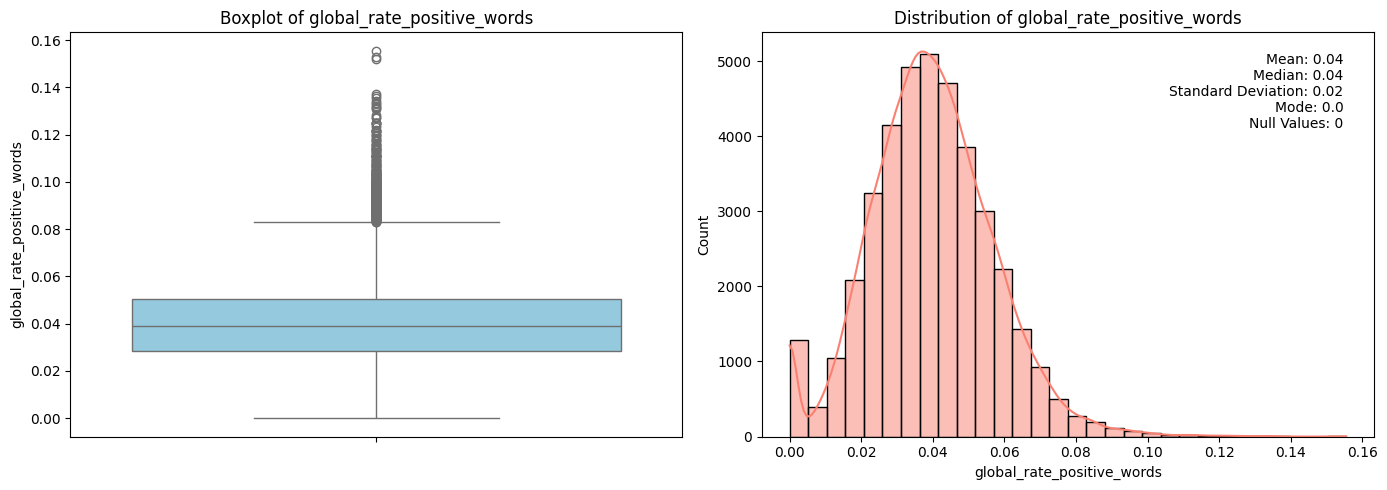

In [ ]:
plot_histogram_and_boxplot_for_column(article_data, 'global_rate_positive_words')


The distribution of positive word rates is right-skewed, with most articles having a low rate.

### global_rate_negative_words

Proportion of negative words in the article.

Statistics for 'global_rate_negative_words':
Mean: 0.016612119534643015
Median: 0.0153374233129
Standard Deviation: 0.010827792187851662
Mode: 0.0
Null Values: 0
--------------------------------------------------


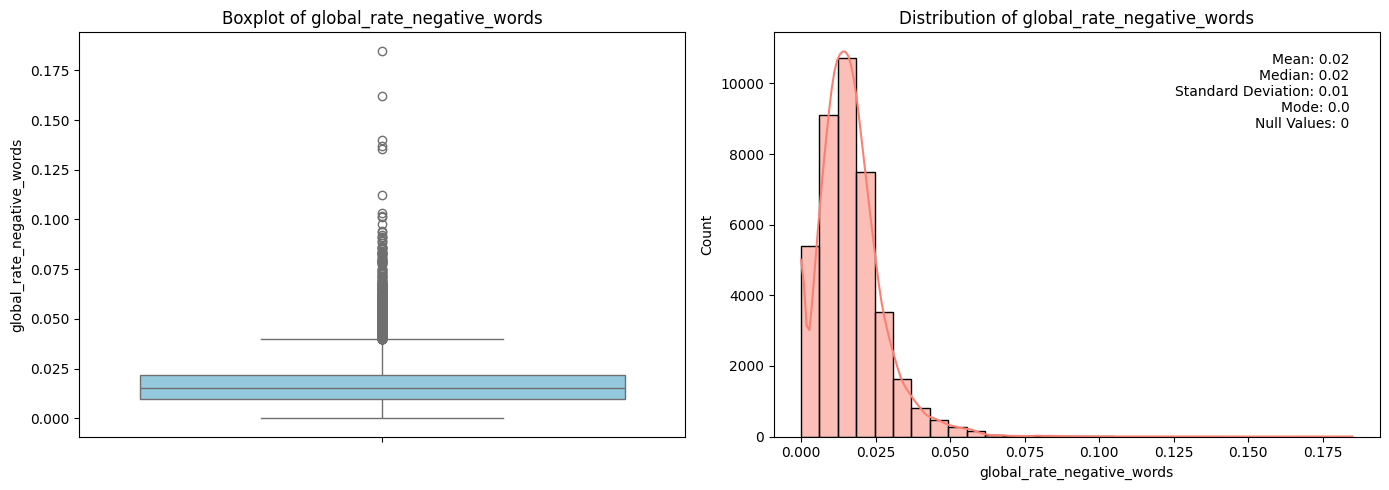

In [ ]:
plot_histogram_and_boxplot_for_column(article_data, 'global_rate_negative_words')


The distribution of negative word rates is right-skewed, with most articles having a low rate. The boxplot reveals some outliers with a higher concentration of negative words.

#### rate_positive_words

Proportion of positive words, excluding neutral ones.

Statistics for 'rate_positive_words':
Mean: 0.6821502211003009
Median: 0.710526315789
Standard Deviation: 0.19020632466079915
Mode: 0.666666666667
Null Values: 0
--------------------------------------------------


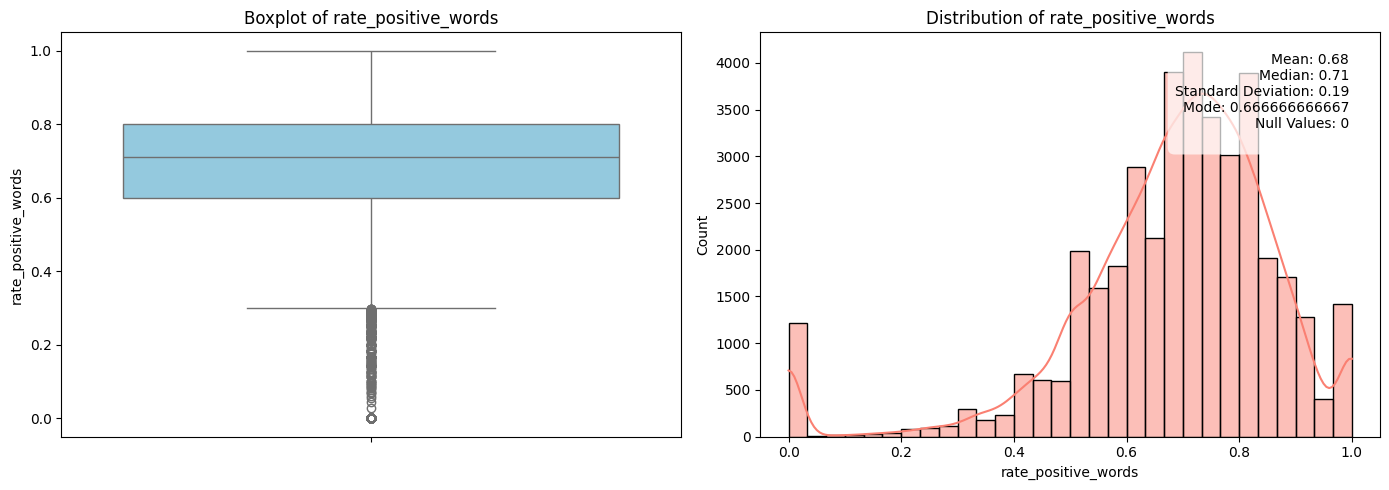

In [ ]:
plot_histogram_and_boxplot_for_column(article_data, 'rate_positive_words')


The distribution of positive word rates is left-skewed, with most articles having a high proportion of positive words. The boxplot shows some outliers with lower positive word rates.









### rate_negative_words

Proportion of negative words, excluding neutral ones.

Statistics for 'rate_negative_words':
Mean: 0.2879335242331674
Median: 0.28
Standard Deviation: 0.1561558879818461
Mode: 0.0
Null Values: 0
--------------------------------------------------


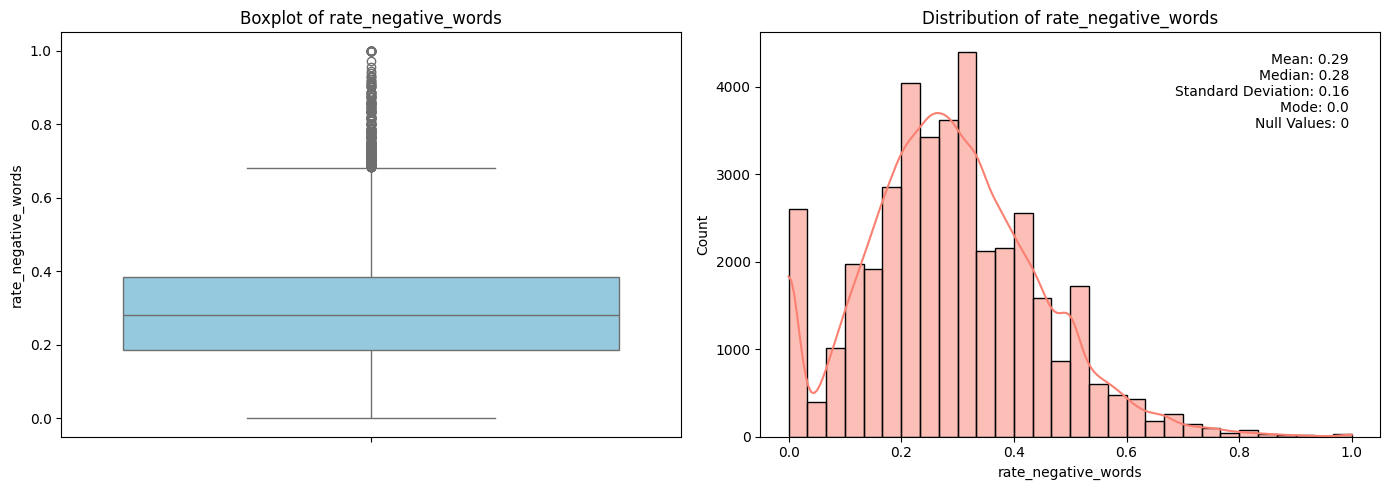

In [ ]:
plot_histogram_and_boxplot_for_column(article_data, 'rate_negative_words')


The distribution of negative word rates is right-skewed, with most articles having a moderate proportion of negative words. The boxplot shows several high-value outliers.

#### avg_positive_polarity

Average positivity of the positive words in the article.

Statistics for 'avg_positive_polarity':
Mean: 0.35382494340707155
Median: 0.3587551652895
Standard Deviation: 0.10454218830821896
Mode: 0.0
Null Values: 0
--------------------------------------------------


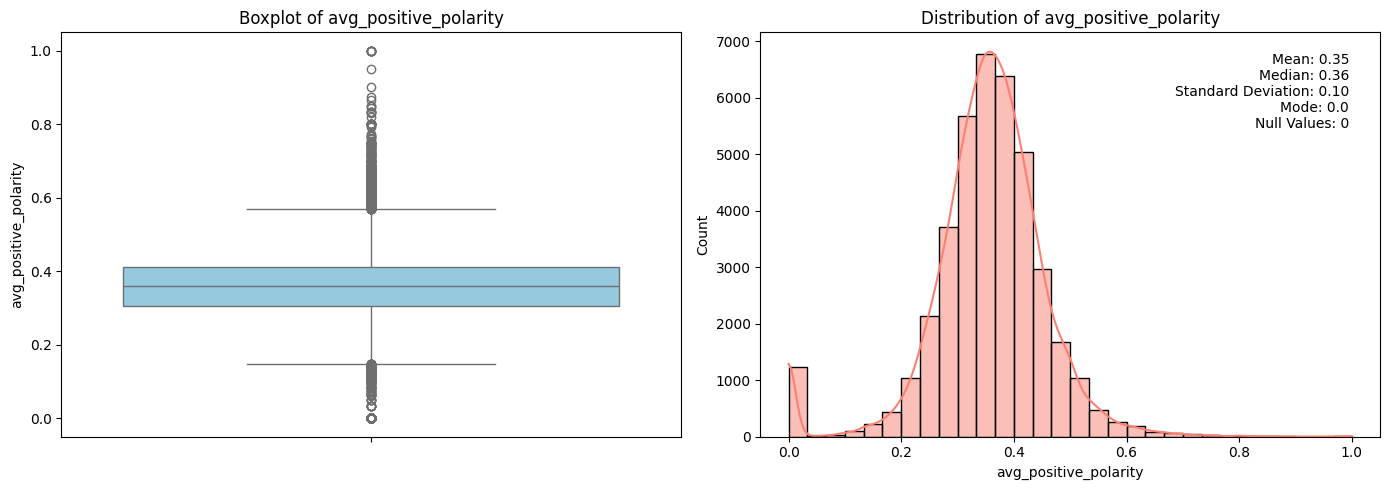

In [ ]:
plot_histogram_and_boxplot_for_column(article_data, 'avg_positive_polarity')


The average positive polarity is centered around 0.35, with a fairly symmetrical distribution. The boxplot indicates some high outliers.

#### min_positive_polarity

Minimum positivity score among the positive words

Statistics for 'min_positive_polarity':
Mean: 0.09544553807024497
Median: 0.1
Standard Deviation: 0.07131493174568221
Mode: 0.1
Null Values: 0
--------------------------------------------------


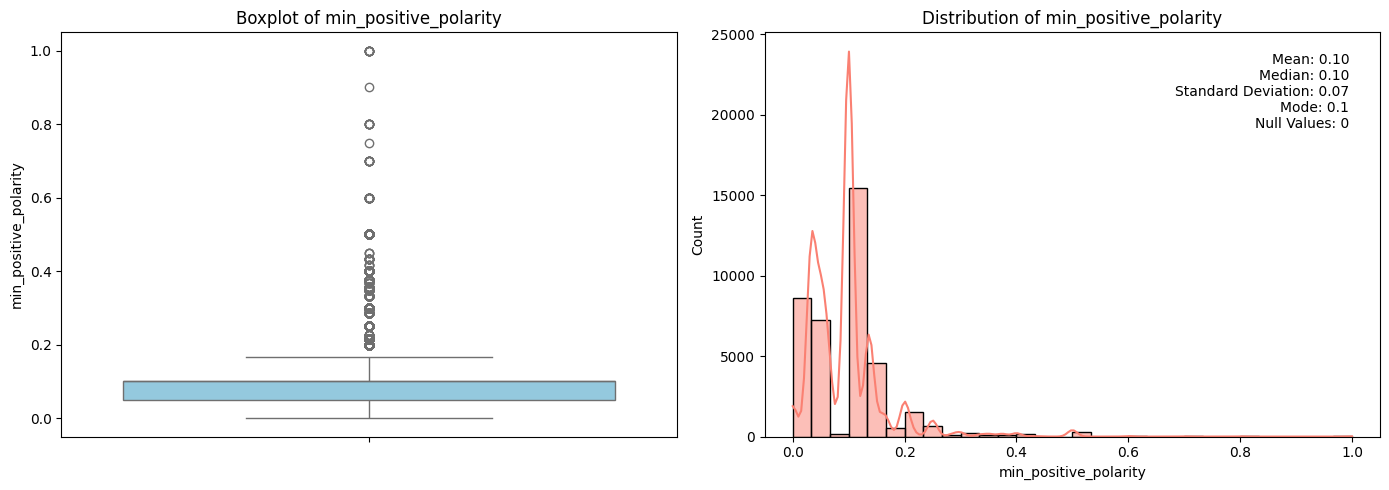

In [ ]:
plot_histogram_and_boxplot_for_column(article_data, 'min_positive_polarity')


The minimum positive polarity is concentrated around 0.10, with a relatively small standard deviation of 0.07. The boxplot shows a significant number of outliers, likely representing articles with higher-than-usual minimum positive polarity values.

#### max_positive_polarity

Maximum positivity score among the positive words.

Statistics for 'max_positive_polarity':
Mean: 0.7567275436995321
Median: 0.8
Standard Deviation: 0.24778571839481928
Mode: 1.0
Null Values: 0
--------------------------------------------------


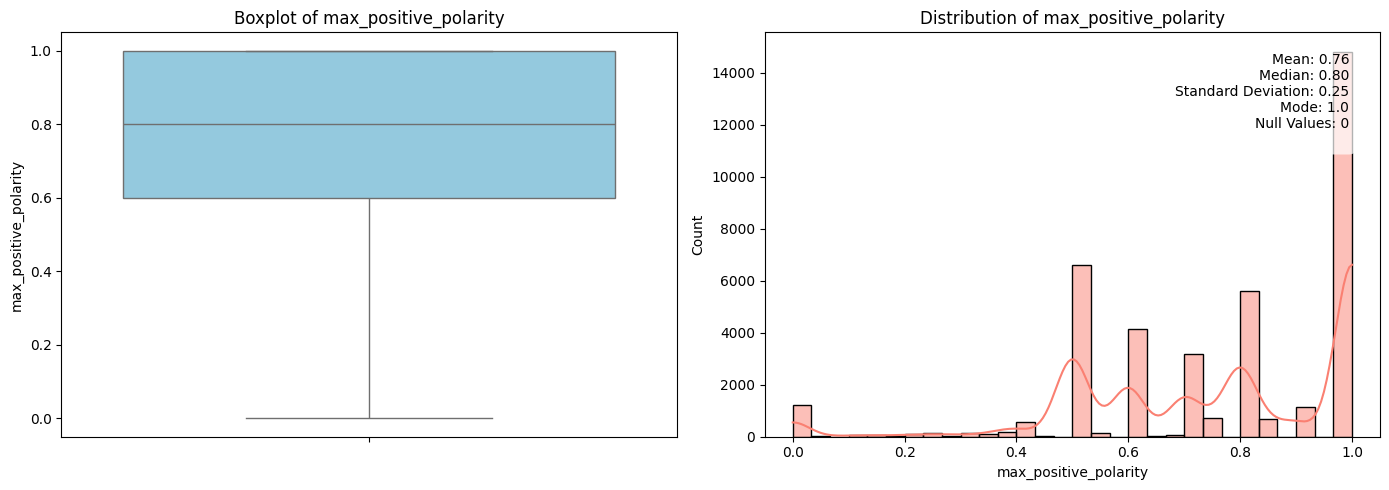

In [ ]:
plot_histogram_and_boxplot_for_column(article_data, 'max_positive_polarity')


The maximum positive polarity values are generally high, with a median of 0.80 and a mode of 1.0, indicating that many articles contain highly positive words.


##### avg_negative_polarity

Average negativity of the negative words in the article.

Statistics for 'avg_negative_polarity':
Mean: -0.25952414109091815
Median: -0.253333333333
Standard Deviation: 0.12772572202940655
Mode: 0.0
Null Values: 0
--------------------------------------------------


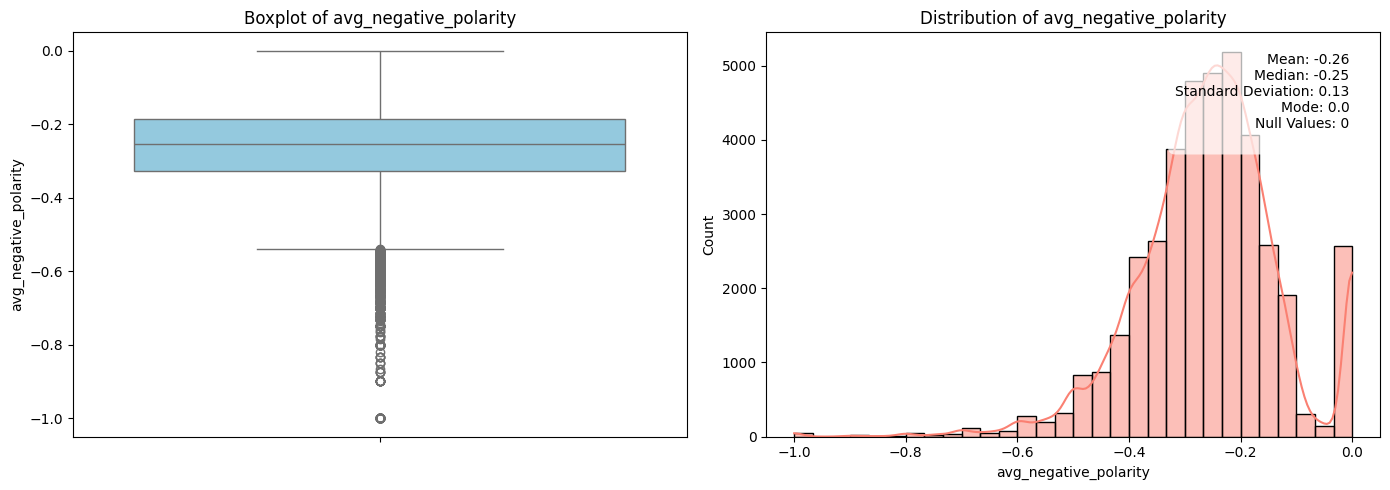

In [ ]:
plot_histogram_and_boxplot_for_column(article_data, 'avg_negative_polarity')


The average negative polarity values are centered around -0.26, with a median of -0.25, indicating a moderate level of negativity in the articles.The boxplot confirms this, showing a compact interquartile range but a significant number of lower outliers, suggesting that some articles contain highly negative words.

#### min_negative_polarity

Minimum negativity score among the negative words.

Statistics for 'min_negative_polarity':
Mean: -0.5219437277484054
Median: -0.5
Standard Deviation: 0.29028950220936445
Mode: -0.5
Null Values: 0
--------------------------------------------------


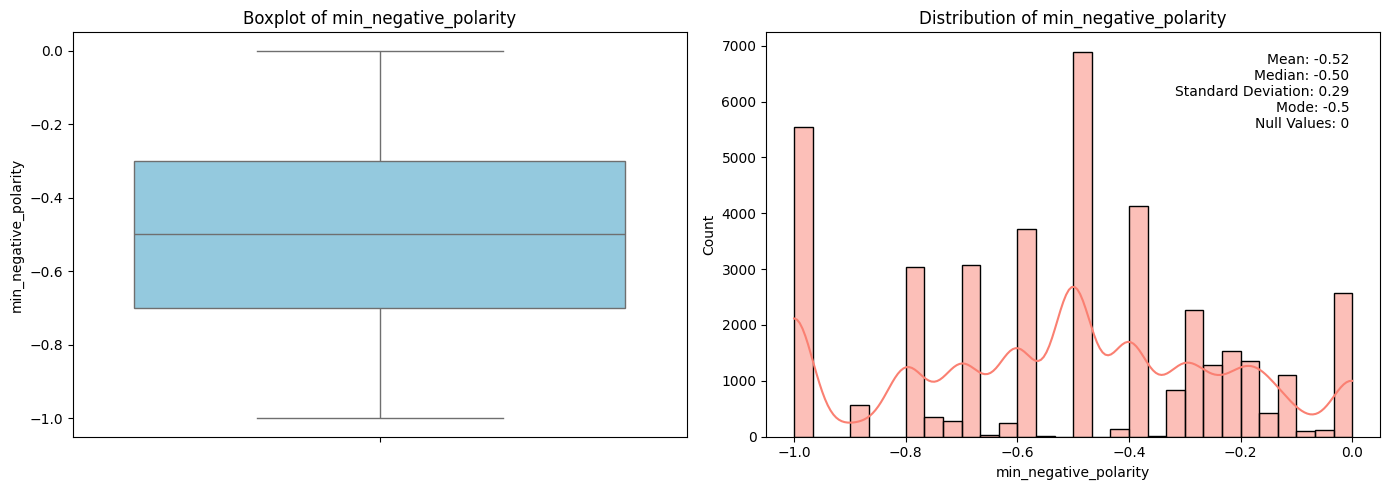

In [ ]:
plot_histogram_and_boxplot_for_column(article_data, 'min_negative_polarity')


The minimum negative polarity values are centered around -0.52, with a median of -0.50, indicating that the most negative words in articles tend to be moderately strong in negativity. The boxplot shows a fairly even spread without significant outliers.

#### max_negative_polarity

Maximum negativity score among the negative words.

Statistics for 'max_negative_polarity':
Mean: -0.10750024015634482
Median: -0.1
Standard Deviation: 0.09537298483252667
Mode: -0.05
Null Values: 0
--------------------------------------------------


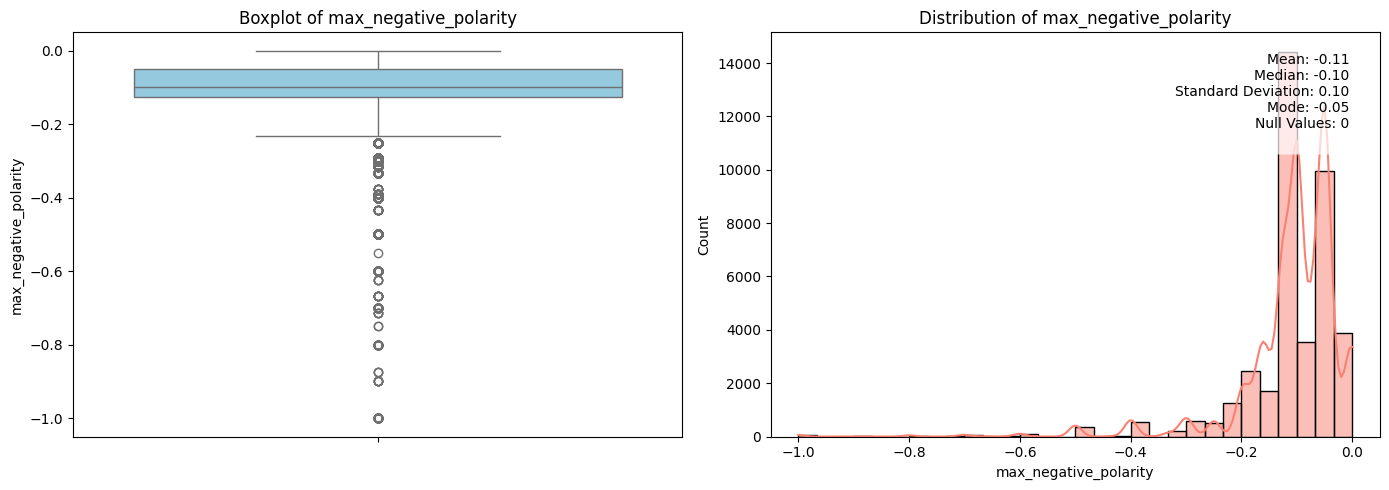

In [ ]:
plot_histogram_and_boxplot_for_column(article_data, 'max_negative_polarity')


The distribution is right-skewed, meaning that most articles use mild negativity, with only a few instances of extreme negativity.

#### title_subjectivity

Subjectivity score of the article's title.

Statistics for 'title_subjectivity':
Mean: 0.2823531841135628
Median: 0.15
Standard Deviation: 0.32424737528929615
Mode: 0.0
Null Values: 0
--------------------------------------------------


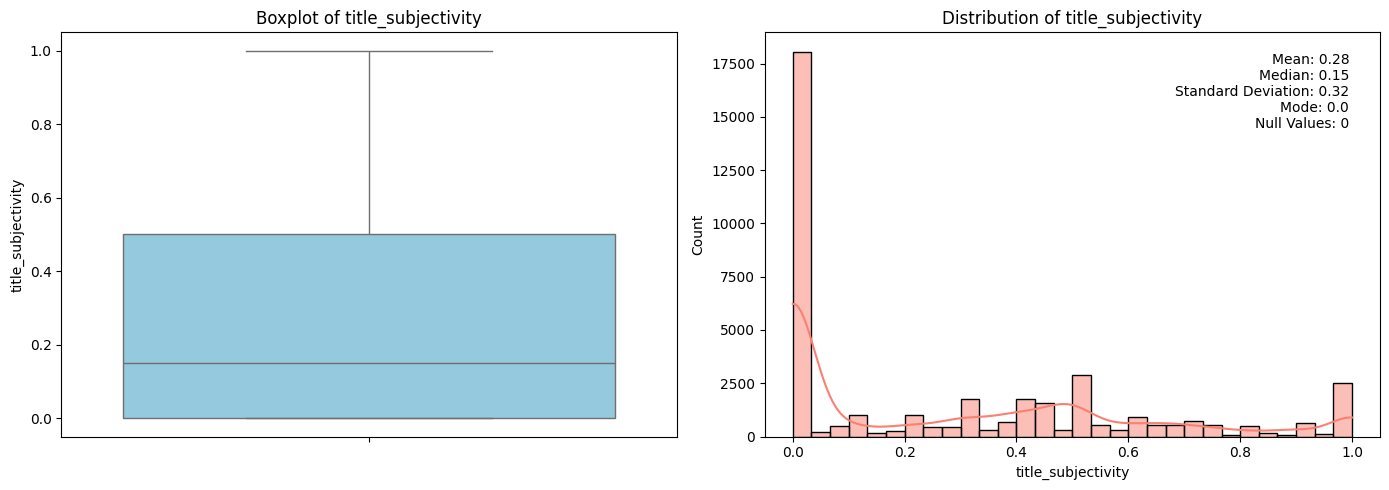

In [ ]:
plot_histogram_and_boxplot_for_column(article_data, 'title_subjectivity')


The title subjectivity values show a mean of 0.28 and a median of 0.15, indicating that most article titles are relatively objective. The boxplot also shows a significant spread, suggesting how subjective different article titles can be.

#### title_sentiment_polarity

Sentiment polarity score (positive or negative) of the article's title.

Statistics for 'title_sentiment_polarity':
Mean: 0.07142543197593561
Median: 0.0
Standard Deviation: 0.26545022913425936
Mode: 0.0
Null Values: 0
--------------------------------------------------


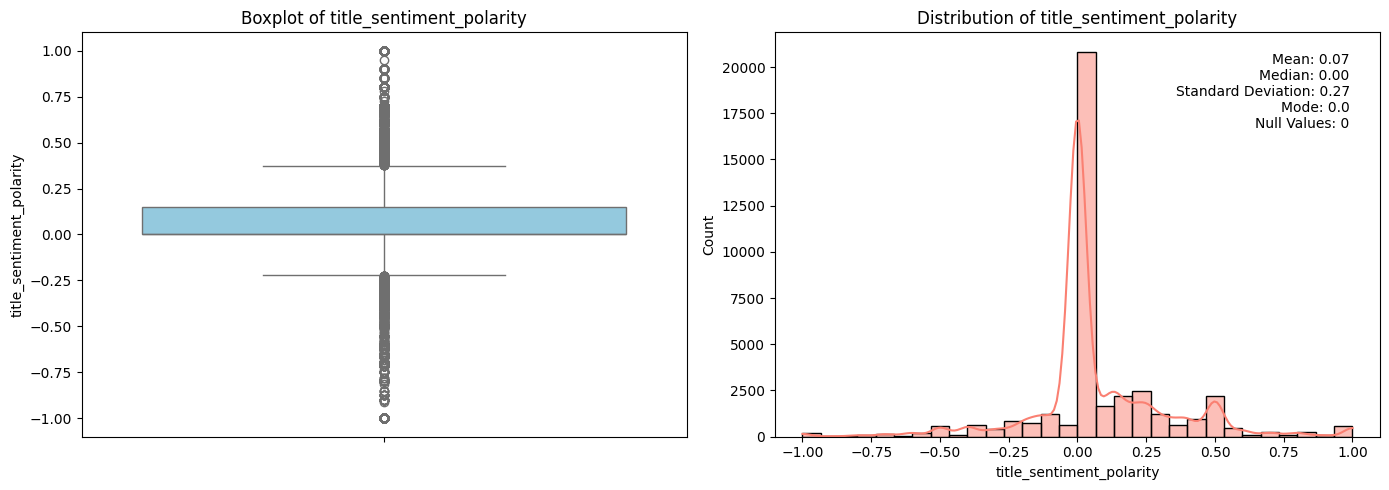

In [ ]:
plot_histogram_and_boxplot_for_column(article_data, 'title_sentiment_polarity')


The title sentiment polarity distribution shows a mean of 0.07 and a median of 0.00, indicating that most titles are neutral in sentiment, the standard deviation of 0.27 and the presence of extreme values (both positive and negative) suggest that some titles contain strong sentiment. The boxplot confirms this by showing outliers at both ends.

#### abs_title_subjectivity

Absolute subjectivity level of the article's title.

Statistics for 'abs_title_subjectivity':
Mean: 0.34184275596034774
Median: 0.5
Standard Deviation: 0.18879080475303386
Mode: 0.5
Null Values: 0
--------------------------------------------------


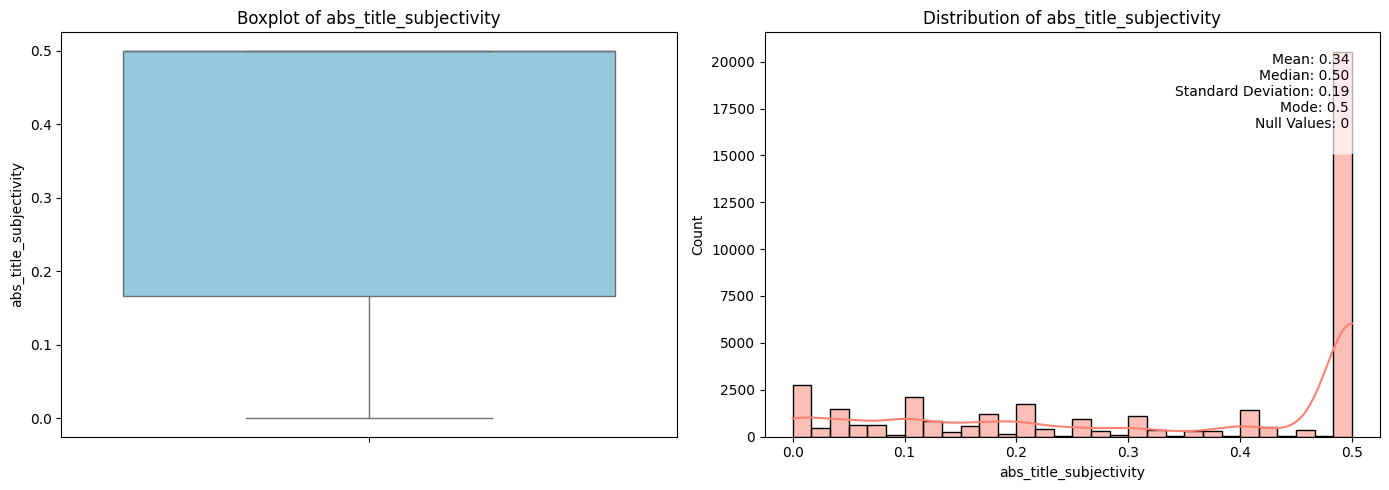

In [ ]:
plot_histogram_and_boxplot_for_column(article_data, 'abs_title_subjectivity')


The boxplot illustrates a wide interquartile range, showing variability in subjectivity levels. The histogram suggests a concentration of values around 0.5, with some articles being either highly objective (close to 0) or highly subjective.

#### abs_title_sentiment_polarity

Absolute sentiment polarity level of the article's title.

Statistics for 'abs_title_sentiment_polarity':
Mean: 0.1560636628565405
Median: 0.0
Standard Deviation: 0.22629419772609116
Mode: 0.0
Null Values: 0
--------------------------------------------------


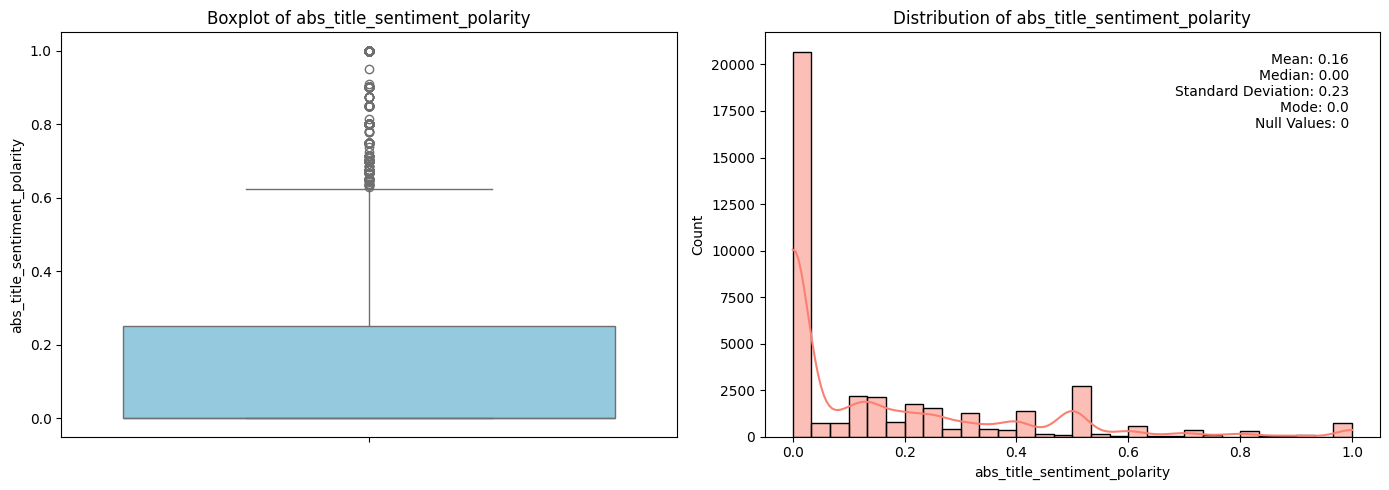

In [ ]:
plot_histogram_and_boxplot_for_column(article_data, 'abs_title_sentiment_polarity')


Most titles have a neutral sentiment, with a mean of 0.16 and a median of 0.00. The boxplot shows some outliers with stronger sentiment, but most values remain close to zero.

Shares

The number of shares the article received.

Statistics for 'shares':
Mean: 3395.3801836343455
Median: 1400.0
Standard Deviation: 11626.950748651716
Mode: 1100
Null Values: 0
--------------------------------------------------


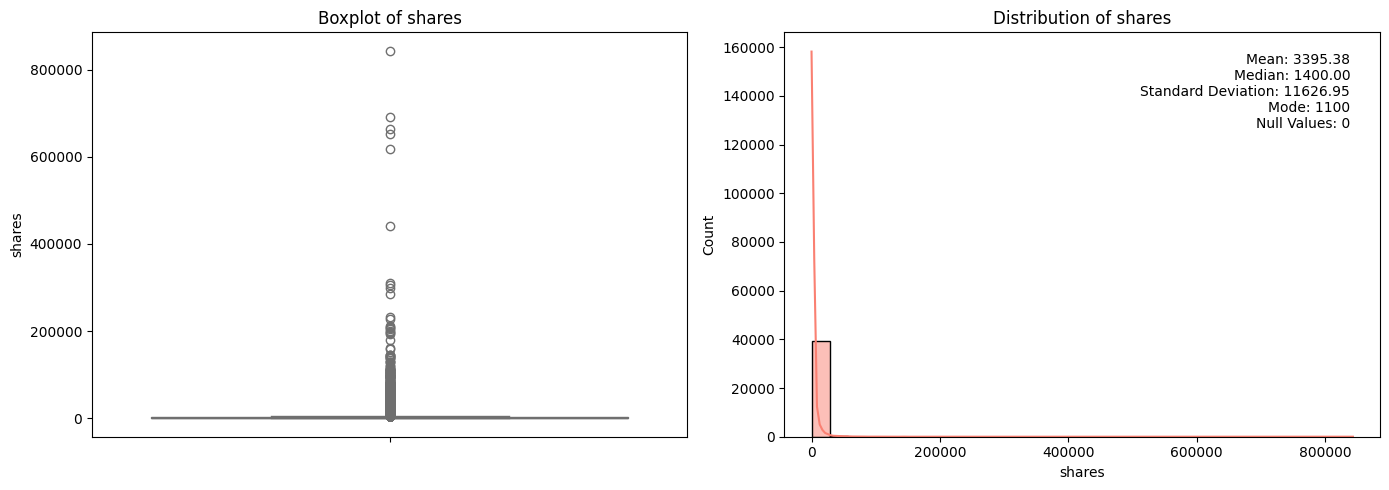

In [ ]:
plot_histogram_and_boxplot_for_column(article_data, 'shares')

Most articles have a low number of shares, with a median of 1,400. However, a few viral articles create extreme outliers, pushing the mean to 3,395.

Extra code (if needed) to add features (e.g., channels 13 to 19) for tidying up the channel information.


---

wide to tidy channeling

#### 2.1.2 Bivariate Analysis

Here we will find correlation with all numerical values to find the features with higher correlation.

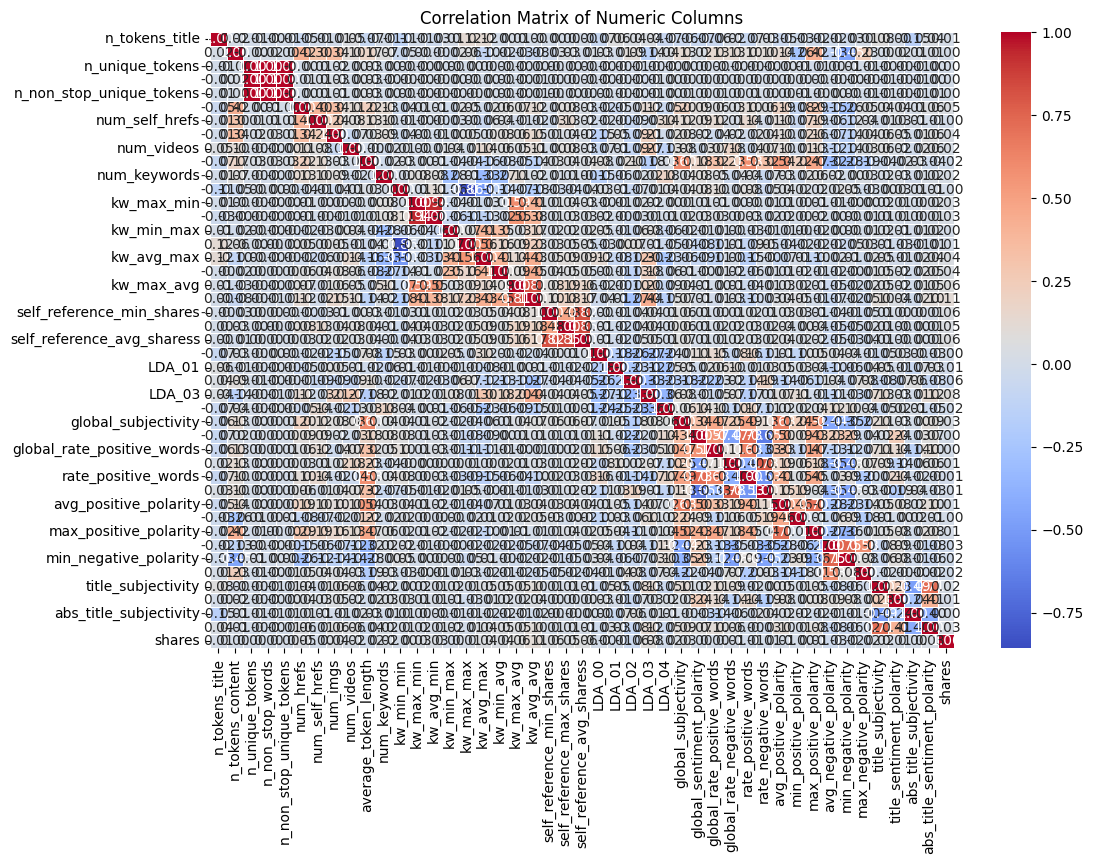

In [ ]:


# Calculate the correlation matrix
corr_matrix = numeric_data.corr()

# Set the size of the plot
plt.figure(figsize=(12, 8))

# Generate the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

# Set title for the heatmap
plt.title('Correlation Matrix of Numeric Columns')

# Show the plot
plt.show()


The heatmap shows correlations between all numeric features, but since there are many variables, it is hard to spot key relationships. The reason we did this is because correlation values or filtering for higher correlations will help us identify patterns.

In [ ]:


# Calculate the correlation matrix for the full article_data DataFrame
article_data.corr()



,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,average_token_length,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
n_tokens_title,1.000000,0.018160,-0.005318,-0.004754,-0.005420,-0.053496,-0.014856,-0.008858,0.051460,-0.071403,...,-0.025069,-0.021662,-0.017096,-0.029146,0.011425,0.077245,0.000240,-0.146954,0.040550,0.008783
n_tokens_content,0.018160,1.000000,-0.004737,0.017512,0.000373,0.423065,0.304682,0.342600,0.103699,0.167789,...,-0.261493,0.415706,-0.130375,-0.450603,0.225870,0.004484,0.023358,0.007136,0.013439,0.002459
n_unique_tokens,-0.005318,-0.004737,1.000000,0.999572,0.999852,-0.004352,0.006620,0.018802,-0.000597,0.026407,...,0.009193,-0.009054,0.001453,0.009902,-0.007315,-0.004678,-0.002333,-0.009242,-0.004217,0.000806
n_non_stop_words,-0.004754,0.017512,0.999572,1.000000,0.999532,0.005521,0.013598,0.028486,-0.000899,0.031554,...,0.000904,0.002062,-0.001372,-0.001214,-0.000761,-0.005389,-0.001650,-0.008511,-0.004391,0.000443
n_non_stop_unique_tokens,-0.005420,0.000373,0.999852,0.999532,1.000000,-0.004983,0.007584,0.014230,-0.000963,0.034185,...,0.008380,-0.002245,-0.001972,0.004318,-0.006708,-0.005860,-0.002910,-0.008572,-0.005342,0.000114
num_hrefs,-0.053496,0.423065,-0.004352,0.005521,-0.004983,1.000000,0.396452,0.342633,0.114518,0.222588,...,-0.082168,0.286733,-0.152146,-0.263576,0.054948,0.043950,0.039041,0.009443,0.056525,0.045404
num_self_hrefs,-0.014856,0.304682,0.006620,0.013598,0.007584,0.396452,1.000000,0.238586,0.077458,0.126879,...,-0.072648,0.189922,-0.058222,-0.122071,0.039153,-0.011239,0.026224,0.008961,-0.006709,-0.001900
num_imgs,-0.008858,0.342600,0.018802,0.028486,0.014230,0.342633,0.238586,1.000000,-0.067336,0.033924,...,-0.024683,0.155232,-0.072500,-0.136522,0.042644,0.056815,0.046310,-0.013759,0.063307,0.039388
num_videos,0.051460,0.103699,-0.000597,-0.000899,-0.000963,0.114518,0.077458,-0.067336,1.000000,-0.002940,...,-0.010103,0.125659,-0.115976,-0.138190,0.027251,0.061028,0.021980,-0.021982,0.055231,0.023936
average_token_length,-0.071403,0.167789,0.026407,0.031554,0.034185,0.222588,0.126879,0.033924,-0.002940,1.000000,...,0.222207,0.471383,-0.324529,-0.278784,-0.194660,-0.040406,-0.016718,0.026586,-0.036953,-0.022007


- **Strong Correlations**:  
  - `n_tokens_content` & `num_hrefs`: **0.42**  
  - `average_token_length` & `max_positive_polarity`: **0.47**

- **Weak Correlations**:  
  - `n_tokens_title` & `shares`: **0.008**  
  - `data_channel_is_bus` & `max_negative_polarity`: **-0.07**

In [ ]:
binary_data.head()

,data_channel_is_lifestyle,data_channel_is_entertainment,data_channel_is_bus,data_channel_is_socmed,data_channel_is_tech,data_channel_is_world,weekday_is_monday,weekday_is_tuesday,weekday_is_wednesday,weekday_is_thursday,weekday_is_friday,weekday_is_saturday,weekday_is_sunday,is_weekend
0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
numeric_data.corr()


,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,average_token_length,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
n_tokens_title,1.000000,0.018160,-0.005318,-0.004754,-0.005420,-0.053496,-0.014856,-0.008858,0.051460,-0.071403,...,-0.025069,-0.021662,-0.017096,-0.029146,0.011425,0.077245,0.000240,-0.146954,0.040550,0.008783
n_tokens_content,0.018160,1.000000,-0.004737,0.017512,0.000373,0.423065,0.304682,0.342600,0.103699,0.167789,...,-0.261493,0.415706,-0.130375,-0.450603,0.225870,0.004484,0.023358,0.007136,0.013439,0.002459
n_unique_tokens,-0.005318,-0.004737,1.000000,0.999572,0.999852,-0.004352,0.006620,0.018802,-0.000597,0.026407,...,0.009193,-0.009054,0.001453,0.009902,-0.007315,-0.004678,-0.002333,-0.009242,-0.004217,0.000806
n_non_stop_words,-0.004754,0.017512,0.999572,1.000000,0.999532,0.005521,0.013598,0.028486,-0.000899,0.031554,...,0.000904,0.002062,-0.001372,-0.001214,-0.000761,-0.005389,-0.001650,-0.008511,-0.004391,0.000443
n_non_stop_unique_tokens,-0.005420,0.000373,0.999852,0.999532,1.000000,-0.004983,0.007584,0.014230,-0.000963,0.034185,...,0.008380,-0.002245,-0.001972,0.004318,-0.006708,-0.005860,-0.002910,-0.008572,-0.005342,0.000114
num_hrefs,-0.053496,0.423065,-0.004352,0.005521,-0.004983,1.000000,0.396452,0.342633,0.114518,0.222588,...,-0.082168,0.286733,-0.152146,-0.263576,0.054948,0.043950,0.039041,0.009443,0.056525,0.045404
num_self_hrefs,-0.014856,0.304682,0.006620,0.013598,0.007584,0.396452,1.000000,0.238586,0.077458,0.126879,...,-0.072648,0.189922,-0.058222,-0.122071,0.039153,-0.011239,0.026224,0.008961,-0.006709,-0.001900
num_imgs,-0.008858,0.342600,0.018802,0.028486,0.014230,0.342633,0.238586,1.000000,-0.067336,0.033924,...,-0.024683,0.155232,-0.072500,-0.136522,0.042644,0.056815,0.046310,-0.013759,0.063307,0.039388
num_videos,0.051460,0.103699,-0.000597,-0.000899,-0.000963,0.114518,0.077458,-0.067336,1.000000,-0.002940,...,-0.010103,0.125659,-0.115976,-0.138190,0.027251,0.061028,0.021980,-0.021982,0.055231,0.023936
average_token_length,-0.071403,0.167789,0.026407,0.031554,0.034185,0.222588,0.126879,0.033924,-0.002940,1.000000,...,0.222207,0.471383,-0.324529,-0.278784,-0.194660,-0.040406,-0.016718,0.026586,-0.036953,-0.022007


### Correlation Findings

#### Positive Correlation Examples:
- **n_tokens_content and num_hrefs**: A correlation of **0.423** indicates a **moderate positive correlation**. As `n_tokens_content` increases, `num_hrefs` tends to increase as well.

#### Negative Correlation Examples:
- **average_token_length and num_videos**: A correlation of **-0.036** suggests a **very weak negative correlation**. As `average_token_length` increases, `num_videos` tends to decrease very slightly.


In [ ]:
# Grouping columns based on their purpose

# Text and Content Features
text_content_features = [
    'n_tokens_title', 'n_tokens_content', 'n_unique_tokens',
    'n_non_stop_words', 'n_non_stop_unique_tokens', 'num_hrefs',
    'num_self_hrefs', 'num_imgs', 'num_videos', 'average_token_length',
    'num_keywords'
]

# Weekday Features (Binary columns indicating each day of the week)
weekday_features = [
    'weekday_is_monday', 'weekday_is_tuesday', 'weekday_is_wednesday',
    'weekday_is_thursday', 'weekday_is_friday', 'weekday_is_saturday',
    'weekday_is_sunday', 'is_weekend'
]

# Data Channel Features (Binary columns indicating which channel)
data_channel_features = [
    'data_channel_is_lifestyle', 'data_channel_is_entertainment',
    'data_channel_is_bus', 'data_channel_is_socmed', 'data_channel_is_tech',
    'data_channel_is_world'
]

# Keyword Features (Keyword statistics)
keyword_features = [
    'kw_min_min', 'kw_max_min', 'kw_avg_min', 'kw_min_max', 'kw_max_max',
    'kw_avg_max', 'kw_min_avg', 'kw_max_avg', 'kw_avg_avg'
]

# Self-reference Features (Self-reference shares statistics)
self_reference_features = [
    'self_reference_min_shares', 'self_reference_max_shares', 'self_reference_avg_sharess'
]

# Sentiment and Subjectivity Features
sentiment_subjectivity_features = [
    'global_subjectivity', 'global_sentiment_polarity', 'global_rate_positive_words',
    'global_rate_negative_words', 'rate_positive_words', 'rate_negative_words',
    'avg_positive_polarity', 'min_positive_polarity', 'max_positive_polarity',
    'avg_negative_polarity', 'min_negative_polarity', 'max_negative_polarity',
    'title_subjectivity', 'title_sentiment_polarity', 'abs_title_subjectivity',
    'abs_title_sentiment_polarity'
]

# LDA Features (Latent Dirichlet Allocation topics)
lda_features = [
    'LDA_00', 'LDA_01', 'LDA_02', 'LDA_03', 'LDA_04'
]

# Numeric Columns (The columns that are numeric and can be used for analysis)
numeric_columns = [
    'shares'  # This would be your target variable, often numeric
]

# Combine all the groups into a dictionary for easy reference
column_groups = {
    "Text and Content Features": text_content_features,
    "Weekday Features": weekday_features,
    "Data Channel Features": data_channel_features,
    "Keyword Features": keyword_features,
    "Self-reference Features": self_reference_features,
    "Sentiment and Subjectivity Features": sentiment_subjectivity_features,
    "LDA Features": lda_features,
    "Numeric Columns": numeric_columns
}

# Display the grouped columns
for group, columns in column_groups.items():
    print(f"{group}: {columns}\n")


Text and Content Features: ['n_tokens_title', 'n_tokens_content', 'n_unique_tokens', 'n_non_stop_words', 'n_non_stop_unique_tokens', 'num_hrefs', 'num_self_hrefs', 'num_imgs', 'num_videos', 'average_token_length', 'num_keywords']

Weekday Features: ['weekday_is_monday', 'weekday_is_tuesday', 'weekday_is_wednesday', 'weekday_is_thursday', 'weekday_is_friday', 'weekday_is_saturday', 'weekday_is_sunday', 'is_weekend']

Data Channel Features: ['data_channel_is_lifestyle', 'data_channel_is_entertainment', 'data_channel_is_bus', 'data_channel_is_socmed', 'data_channel_is_tech', 'data_channel_is_world']

Keyword Features: ['kw_min_min', 'kw_max_min', 'kw_avg_min', 'kw_min_max', 'kw_max_max', 'kw_avg_max', 'kw_min_avg', 'kw_max_avg', 'kw_avg_avg']

Self-reference Features: ['self_reference_min_shares', 'self_reference_max_shares', 'self_reference_avg_sharess']

Sentiment and Subjectivity Features: ['global_subjectivity', 'global_sentiment_polarity', 'global_rate_positive_words', 'global_rate_n

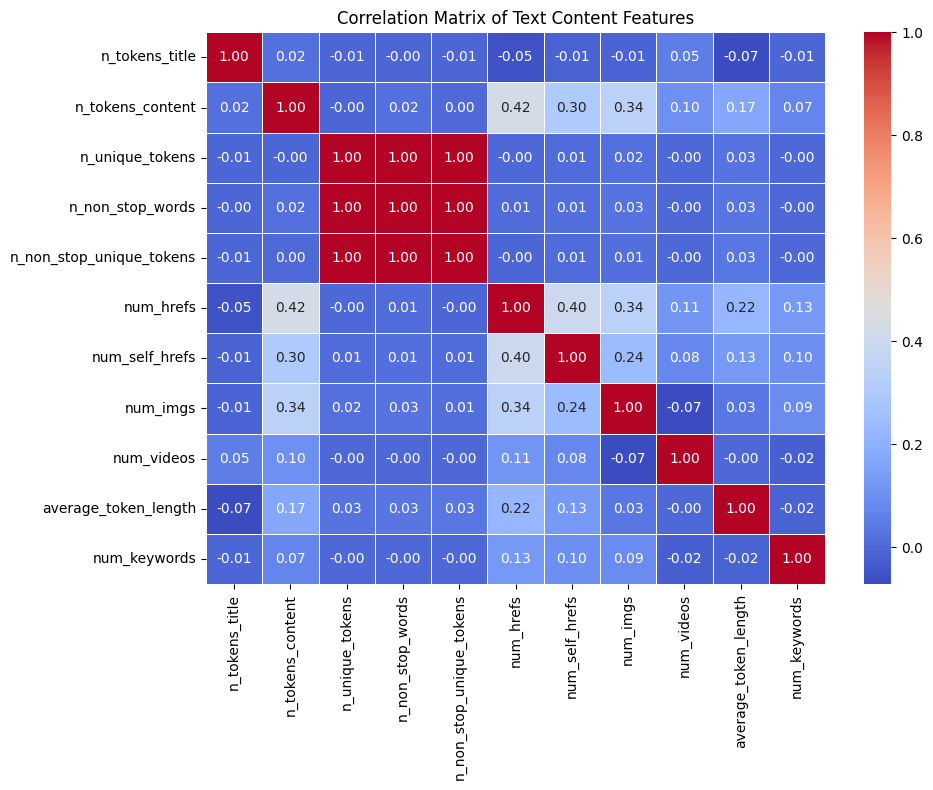

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select the relevant columns for the correlation matrix
correlation_content_data = numeric_data[text_content_features]

# Compute the correlation matrix
correlation_matrix = correlation_content_data.corr()

# Plot the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

# Set title
plt.title('Correlation Matrix of Text Content Features')

# Show the plot
plt.tight_layout()
plt.show()


- The heatmap reveals key correlations among text content features. As noted earlier, **n_tokens_content** and **num_hrefs** show a moderate correlation of **0.42**, while **num_hrefs** and **num_self_hrefs** also have a correlation of **0.4**. Additionally, **n_unique_tokens**, **n_non_stop_words**, and **n_non_stop_unique_tokens** exhibit strong intercorrelations, indicating that articles with more unique words tend to have a higher proportion of non-stop words.

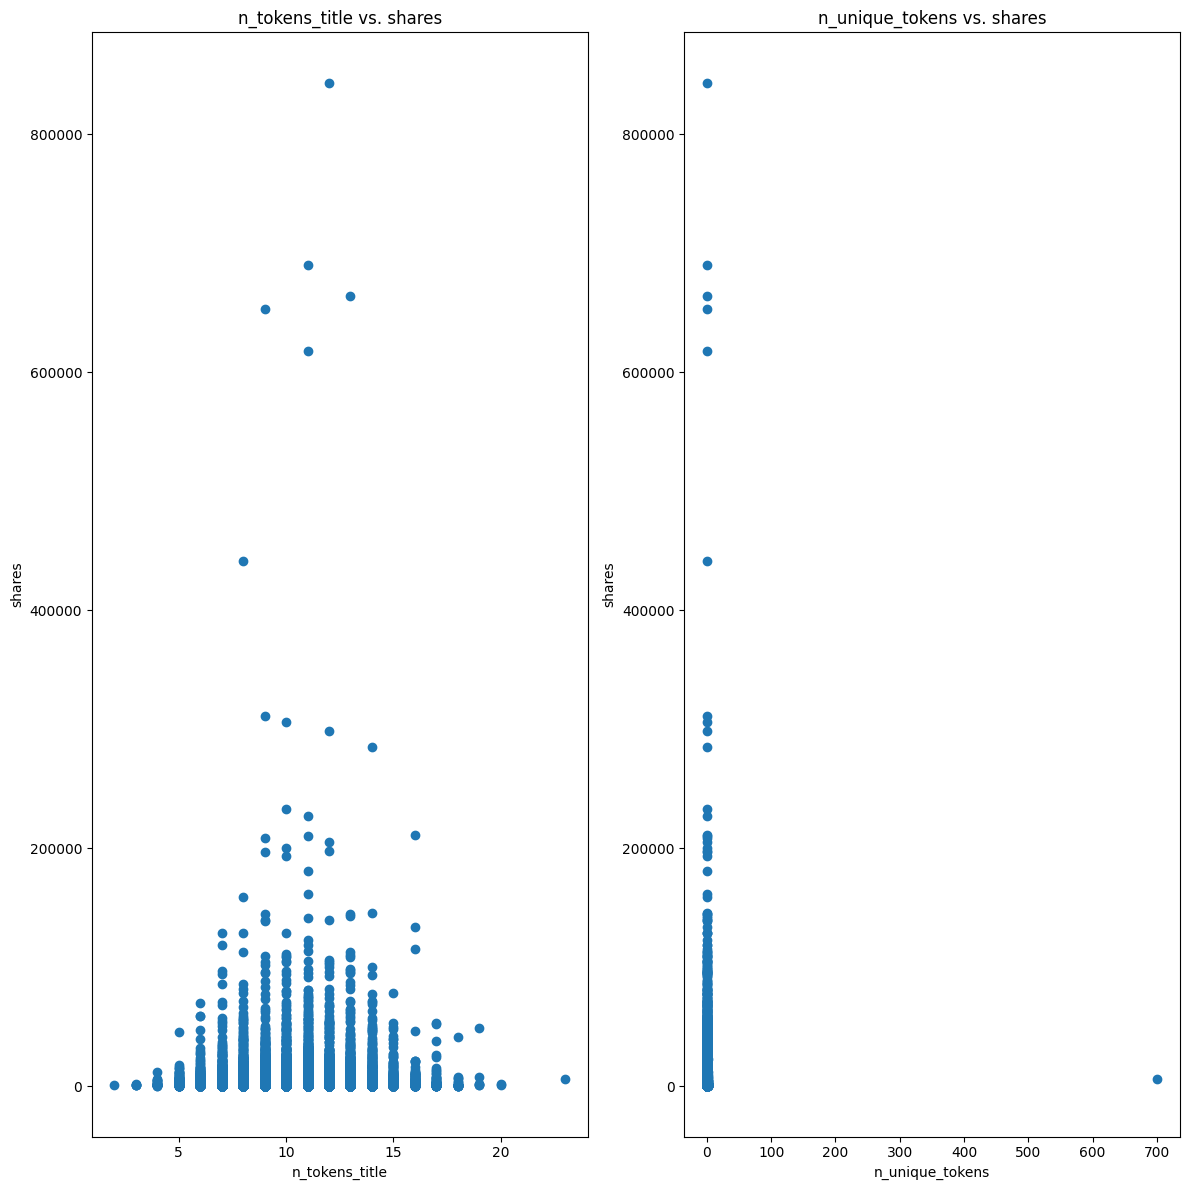

In [ ]:
# Create subplots with 1 row and 2 columns
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 12))

# Scatter plot of n_tokens_title vs. shares
axes[0].scatter(numeric_data['n_tokens_title'], numeric_data['shares'])
axes[0].set_title('n_tokens_title vs. shares')
axes[0].set_xlabel('n_tokens_title')
axes[0].set_ylabel('shares')



# Scatter plot of n_unique_tokens vs. shares
axes[1].scatter(numeric_data['n_unique_tokens'],  numeric_data['shares'])
axes[1].set_title('n_unique_tokens vs. shares')
axes[1].set_xlabel('n_unique_tokens')
axes[1].set_ylabel('shares')

# Display the plots
plt.tight_layout()
plt.show()



- In the **n_tokens_title vs. shares** scatter plot, we can see a pyramid-like shape. Most data points are at the bottom, with fewer as the number of title tokens increases. This suggests that articles with a moderate number of title tokens are more common, while very short or long titles are less frequent.  

- In the **n_unique_tokens vs. shares** plot, the points move in a straight line going up. This shows that as the number of unique tokens increases, the number of shares tends to go up too, but there aren't many extreme values.

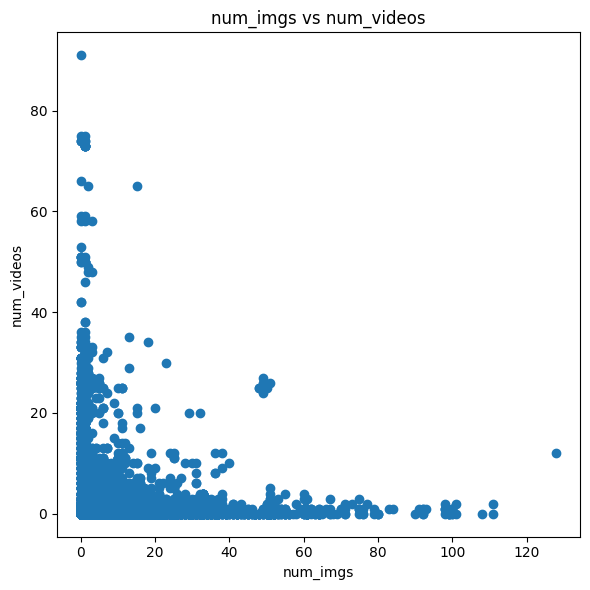

In [ ]:

import matplotlib.pyplot as plt

# Create the first plot (num_imgs vs num_videos)
fig1, ax1 = plt.subplots(figsize=(6, 6))
ax1.scatter(numeric_data['num_imgs'], numeric_data['num_videos'])
ax1.set_title('num_imgs vs num_videos')
ax1.set_xlabel('num_imgs')
ax1.set_ylabel('num_videos')

# Display the first plot
plt.tight_layout()
plt.show()




- Most articles have only a few images and videos, and it's rare to see a lot of both in the same article. When the number of images goes up, the number of videos usually stays low.

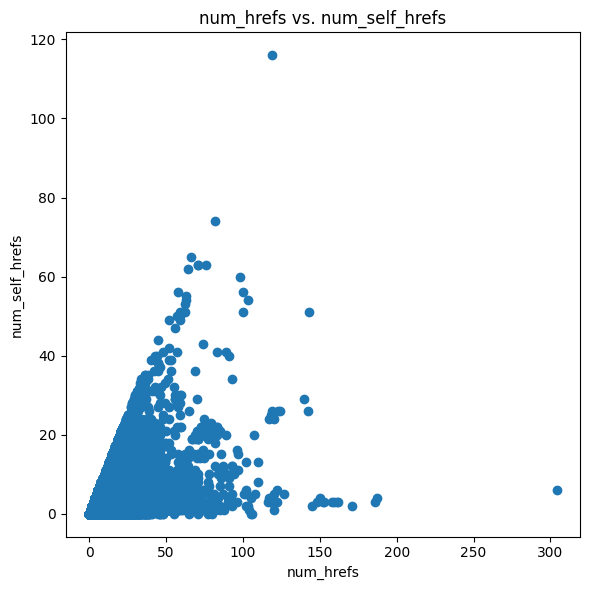

In [ ]:
# Create the second plot (num_hrefs vs num_self_hrefs)
fig2, ax2 = plt.subplots(figsize=(6, 6))
ax2.scatter(numeric_data['num_hrefs'], numeric_data['num_self_hrefs'])
ax2.set_title('num_hrefs vs. num_self_hrefs')
ax2.set_xlabel('num_hrefs')
ax2.set_ylabel('num_self_hrefs')

# Display the second plot
plt.tight_layout()
plt.show()


- Most articles have a small number of links and self-references, as seen in the cluster at the bottom left.
- The triangular shape suggests that as the total number of links increases, self-references also increase but at a slower rate.

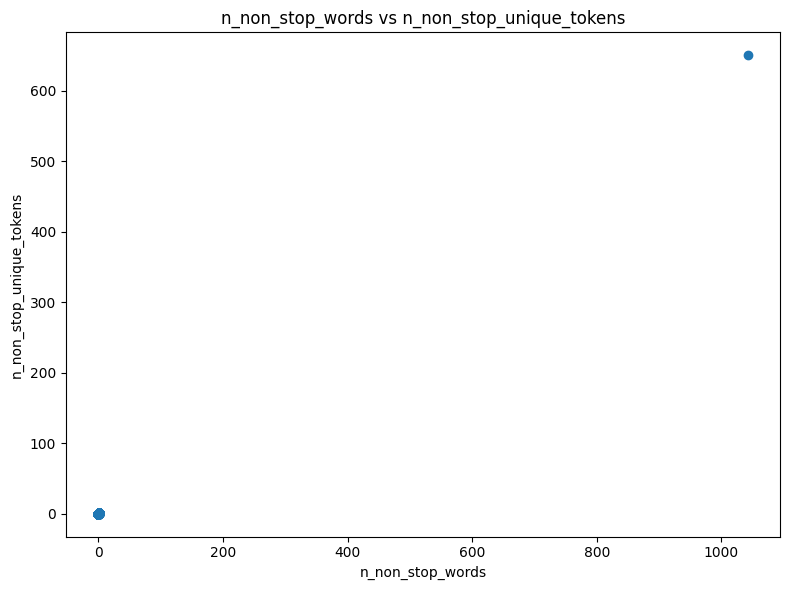

In [ ]:


# Create a scatter plot for n_non_stop_words vs n_non_stop_unique_tokens
plt.figure(figsize=(8, 6))
plt.scatter(numeric_data['n_non_stop_words'], numeric_data['n_non_stop_unique_tokens'])
plt.title('n_non_stop_words vs n_non_stop_unique_tokens')
plt.xlabel('n_non_stop_words')
plt.ylabel('n_non_stop_unique_tokens')

# Display the plot
plt.tight_layout()
plt.show()


- There are only a few points, which might mean some data is missing or limited.
One article has very few non-stop words, while another has a lot more, showing a big difference between them.

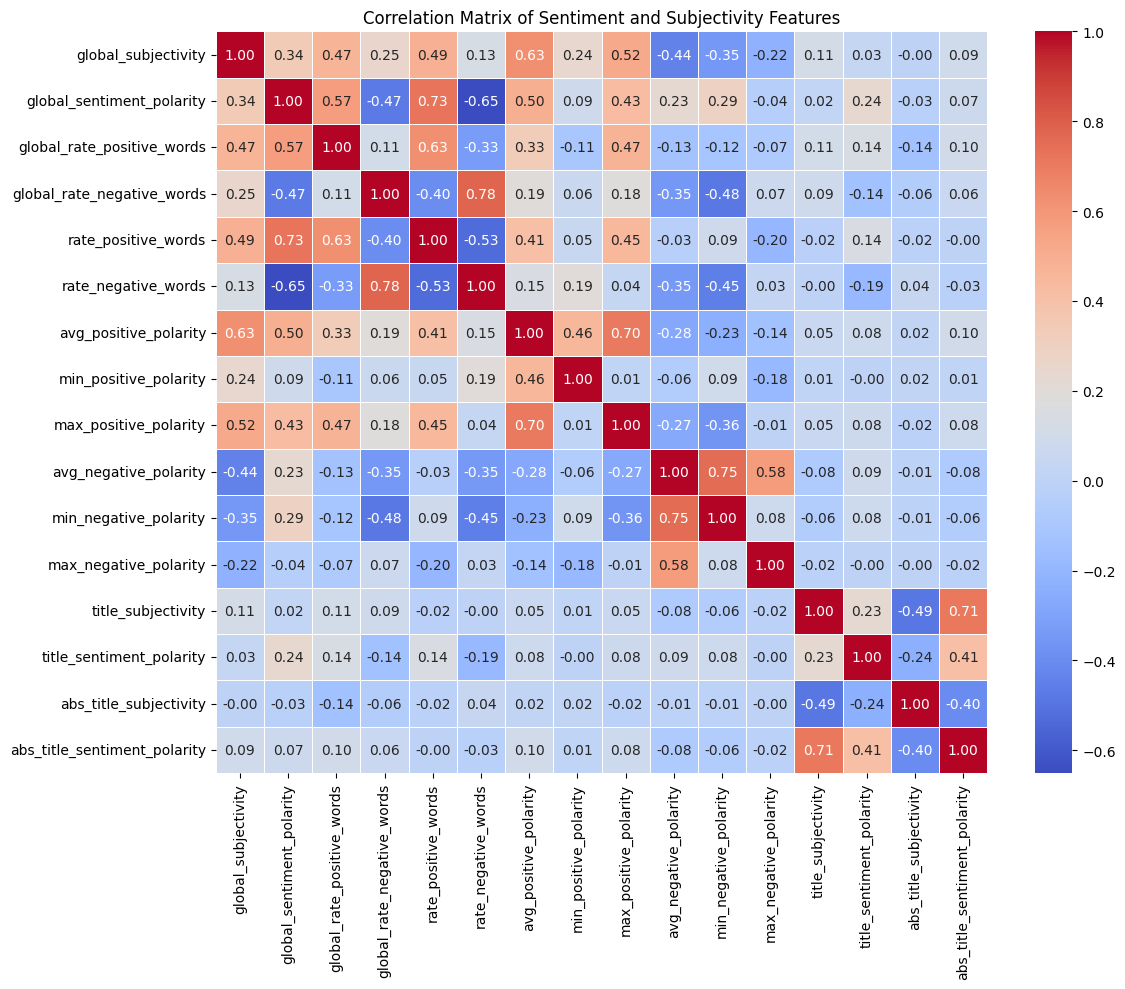

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select the relevant columns for the correlation matrix
correlation_data_sentiment = numeric_data[sentiment_subjectivity_features]

# Compute the correlation matrix
correlation_matrix_sentiment = correlation_data_sentiment.corr()

# Plot the correlation matrix using a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_sentiment, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

# Set title
plt.title('Correlation Matrix of Sentiment and Subjectivity Features')

# Show the plot
plt.tight_layout()
plt.show()


- Articles with more positive words usually have a higher sentiment score.
- Strong connection between avg_negative_polarity and min_negative_polarity since both measure negativity.
- Title sentiment does not strongly relate to the full text, meaning a title’s emotion might not match the article’s tone.

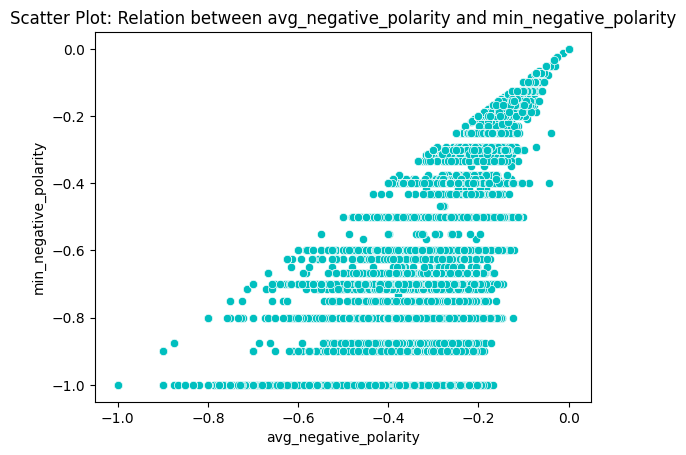

In [ ]:


# Create a scatter plot to explore the relation between avg_negative_polarity and min_negative_polarity
sns.scatterplot(x='avg_negative_polarity', y='min_negative_polarity', data=numeric_data, color='c')

# Add title and display the plot
plt.title('Scatter Plot: Relation between avg_negative_polarity and min_negative_polarity')
plt.xlabel('avg_negative_polarity')
plt.ylabel('min_negative_polarity')

plt.show()


- The points go up in a pattern, meaning that as overall negativity increases, the most negative word also gets more negative.
- Many points are grouped together, which means a lot of articles have similar negativity, likely using common negative words.

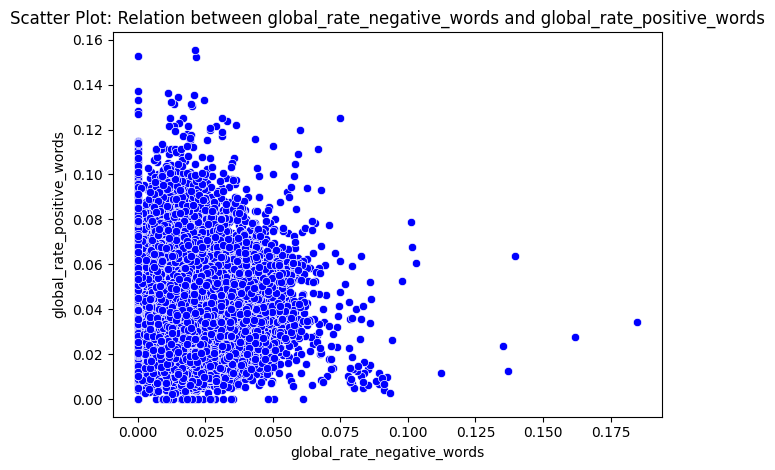

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a scatter plot to explore the relation between global_rate_negative_words and global_rate_positive_words
sns.scatterplot(x='global_rate_negative_words', y='global_rate_positive_words', data=numeric_data, color='b')

# Add title and labels
plt.title('Scatter Plot: Relation between global_rate_negative_words and global_rate_positive_words')
plt.xlabel('global_rate_negative_words')
plt.ylabel('global_rate_positive_words')

# Show the plot
plt.tight_layout()
plt.show()


- There's no clear pattern, meaning that articles with more negative words do not necessarily have more or fewer positive words.
- Most articles have a low percentage of both positive and negative words, which suggests that extreme language is not very common.


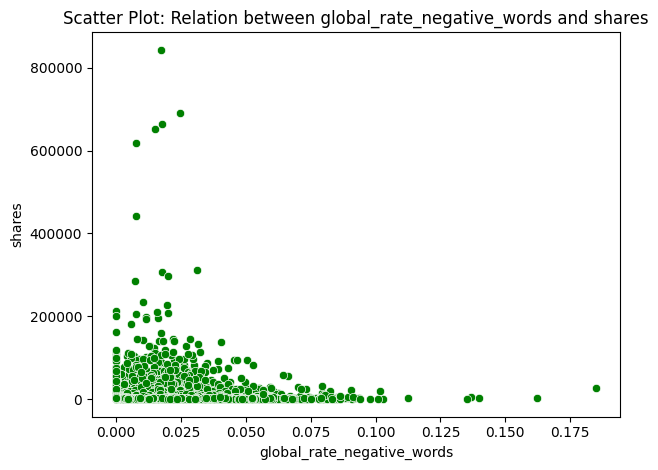

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a scatter plot to explore the relation between global_rate_negative_words and shares
sns.scatterplot(x='global_rate_negative_words', y='shares', data=numeric_data, color='g')

# Add title and labels
plt.title('Scatter Plot: Relation between global_rate_negative_words and shares')
plt.xlabel('global_rate_negative_words')
plt.ylabel('shares')

# Show the plot
plt.tight_layout()
plt.show()


- Articles with more negative words do not seem to get shared more.
- Most articles have a low percentage of negative words, and their shares are mostly under 200,000.

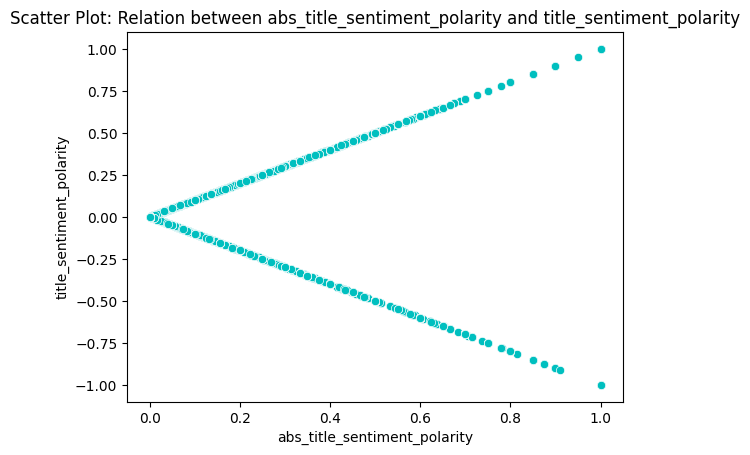

In [ ]:


# Create a scatter plot to explore the relation between abs_title_sentiment_polarity and title_sentiment_polarity
sns.scatterplot(x='abs_title_sentiment_polarity', y='title_sentiment_polarity', data=numeric_data, color='c')

# Add title and display the plot
plt.title('Scatter Plot: Relation between abs_title_sentiment_polarity and title_sentiment_polarity')
plt.xlabel('abs_title_sentiment_polarity')
plt.ylabel('title_sentiment_polarity')

plt.show()


- As the sentiment of a title increases, its actual sentiment moves further from neutral, either becoming more positive or more negative,this explains the V-shape, where stronger sentiments (both positive and negative) appear as the value increases.

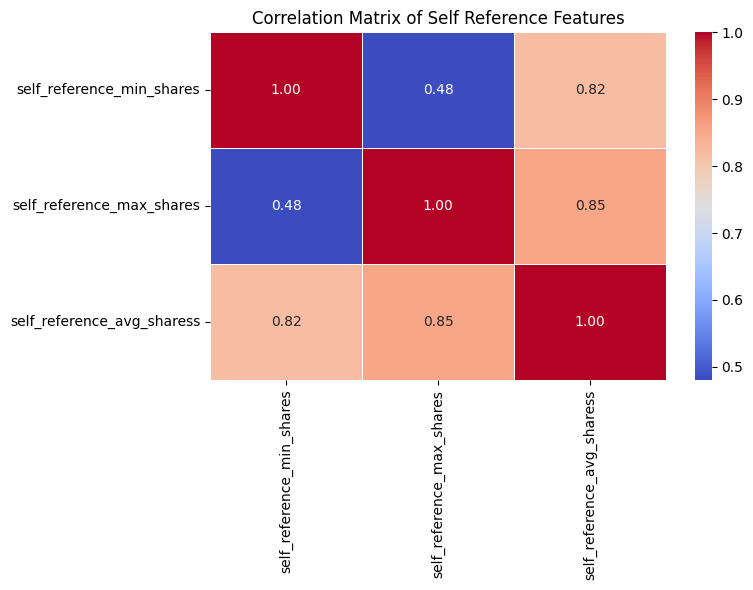

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select the relevant columns for the correlation matrix
correlation_data_self_reference = numeric_data[self_reference_features]

# Compute the correlation matrix
correlation_matrix_self_reference = correlation_data_self_reference.corr()

# Plot the correlation matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix_self_reference, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

# Set title
plt.title('Correlation Matrix of Self Reference Features')

# Show the plot
plt.tight_layout()
plt.show()


Some articles have a big gap between their least and most shared instances.

### self_reference_min_shares vs shares

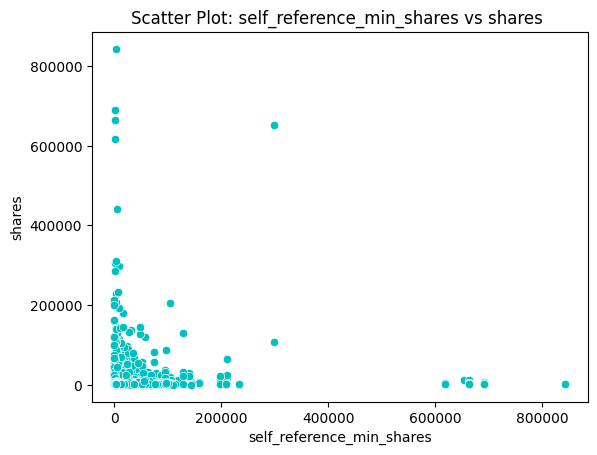

In [ ]:
# Create a scatter plot to explore the relation between abs_title_sentiment_polarity and title_sentiment_polarity
sns.scatterplot(x='self_reference_min_shares', y='shares', data=numeric_data, color='c')

# Add title and display the plot
plt.title('Scatter Plot: self_reference_min_shares vs shares ')
plt.xlabel('self_reference_min_shares')
plt.ylabel('shares')

plt.show()


- Most points are in the lower-left, meaning articles with fewer self-references also have fewer total shares. Some articles get shared a lot even with low self-references; it may be due to other factors that make them more popular.

self_reference_max_shares vs shares

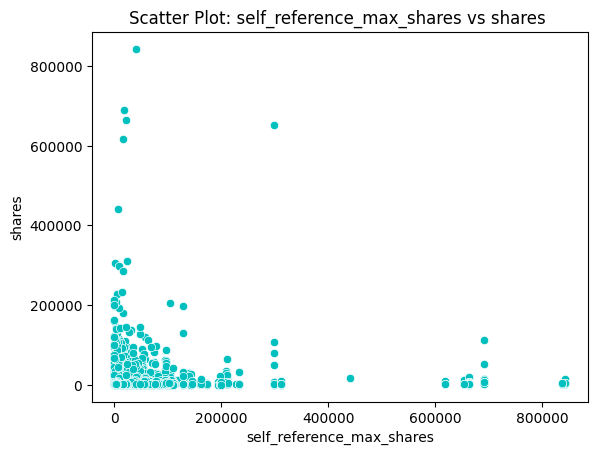

In [ ]:
# Create a scatter plot to explore the relation between abs_title_sentiment_polarity and title_sentiment_polarity
sns.scatterplot(x='self_reference_max_shares', y='shares', data=numeric_data, color='c')

# Add title and display the plot
plt.title('Scatter Plot: self_reference_max_shares vs shares ')
plt.xlabel('self_reference_max_shares')
plt.ylabel('shares')

plt.show()


 - Like the previous graph, most articles do not get shared much, no matter how many self-references they have. The points are a little more scattered, meaning self-referencing might have a small effect on shares.
 - A few stand out with very high shares, but this is not common.

Distribution of Shares by Lifestyle Channel

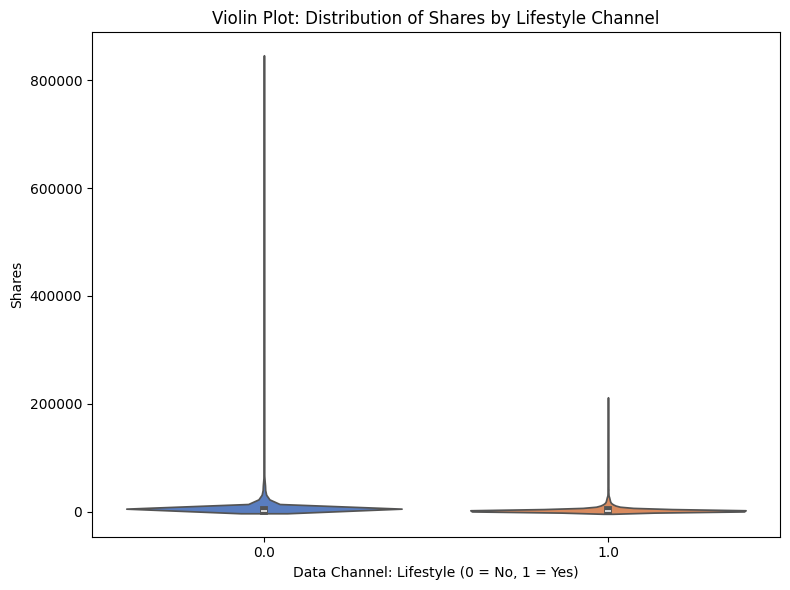

In [ ]:


# Create a violin plot to compare the distribution of 'shares' based on 'data_channel_is_lifestyle'
plt.figure(figsize=(8, 6))
sns.violinplot(x='data_channel_is_lifestyle', y='shares', data=article_data, palette='muted')

# Add title and labels
plt.title('Violin Plot: Distribution of Shares by Lifestyle Channel')
plt.xlabel('Data Channel: Lifestyle (0 = No, 1 = Yes)')
plt.ylabel('Shares')

# Show the plot
plt.tight_layout()
plt.show()


- Most articles, regardless of category, have low shares, meaning viral content is not commom. However, a few non-Lifestyle articles have gone viral with higher shares, while Lifestyle articles have just a few.
- People might enjoy reading Lifestyle content, but they do not share it as much as other types of articles.

Distribution of Sentiment Polarity by Entertainment Channel

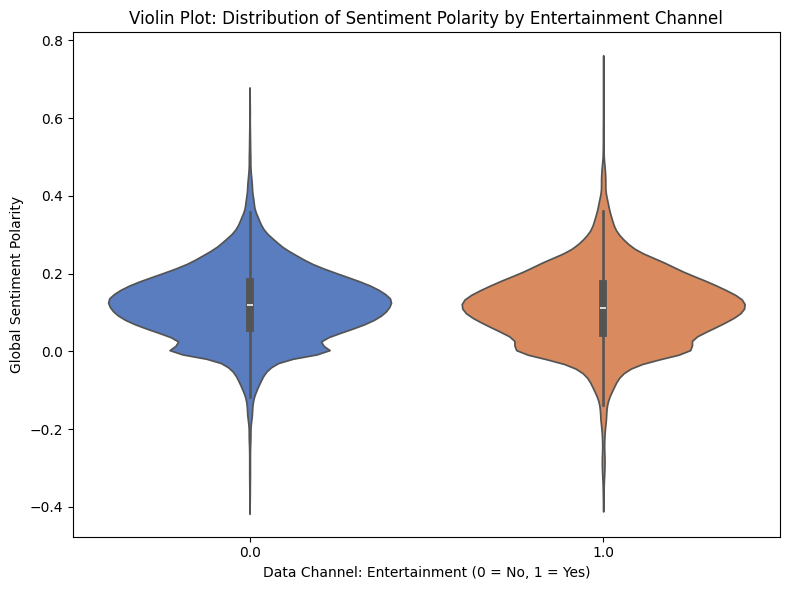

In [ ]:


# Create a violin plot to compare the distribution of 'global_sentiment_polarity' based on 'data_channel_is_entertainment'
plt.figure(figsize=(8, 6))
sns.violinplot(x='data_channel_is_entertainment', y='global_sentiment_polarity', data=article_data, palette='muted')

# Add title and labels
plt.title('Violin Plot: Distribution of Sentiment Polarity by Entertainment Channel')
plt.xlabel('Data Channel: Entertainment (0 = No, 1 = Yes)')
plt.ylabel('Global Sentiment Polarity')

# Show the plot
plt.tight_layout()
plt.show()


- Both Entertainment and non-Entertainment articles usually have a neutral or positive tone, since they look very similar. This suggests that Entertainment content does not have a stronger emotional feel.
- This suggests that how emotional an article is might not be the main reason people share Entertainment content.

### Multivariate Analysis

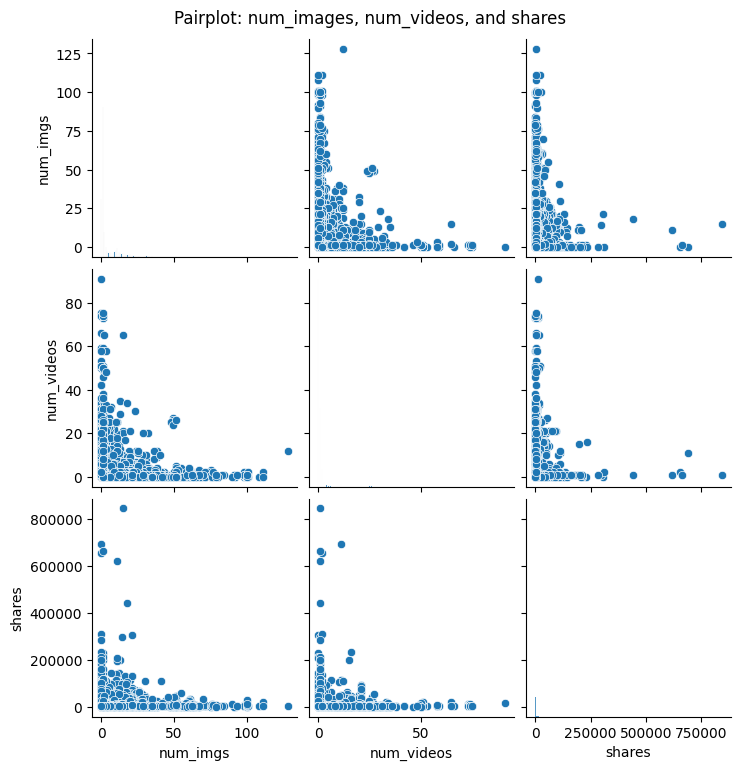

In [ ]:


# Create a pairplot for num_images, num_videos, and shares
sns.pairplot(article_data[['num_imgs', 'num_videos', 'shares']])

# Add title to the plot
plt.suptitle('Pairplot: num_images, num_videos, and shares', y=1.02)

# Display the plot
plt.show()


### Number of Images & Shares  
- Most articles have a small number of images.  
- There is no strong trend showing that more images lead to more shares.  
- A few articles with many images still have low shares, meaning more images do not always mean more engagement.

### Number of Videos & Shares  
- Similar to images, most articles have a few videos.  
- Articles with more videos do not always have higher shares, suggesting that videos alone do not necessarily lead to greater engagement.

There is a slight pattern showing that articles with many images tend to have more videos too. However, neither images nor videos show a clear, strong relationship with shares.

## 3. Feature Selection / Dimensionality Reduction

### 3.1 Correlation Analysis:

In this correlation analysis, we identify features with a correlation coefficient greater than 0.5, considering them highly correlated. To mitigate redundancy and enhance the efficiency of Principal Component Analysis (PCA), we iterate through the correlation matrix, extracting a list of highly correlated feature pairs. Subsequently, we remove one feature from each correlated pair to reduce dimensionality of our dataset.


In [ ]:
# Compute the correlation matrix
correlation_matrix = article_data.corr()

# Identify highly correlated columns (correlation above 0.5)
threshold = 0.5
highly_correlated_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > threshold:
            highly_correlated_pairs.append(
                (correlation_matrix.columns[i], correlation_matrix.columns[j], correlation_matrix.iloc[i, j])
            )

# Convert to DataFrame for easy viewing
correlated_article_data = pd.DataFrame(highly_correlated_pairs, columns=["Feature 1", "Feature 2", "Correlation"])

# Display highly correlated features
print(correlated_article_data)

                       Feature 1                      Feature 2  Correlation
0               n_non_stop_words                n_unique_tokens     0.999572
1       n_non_stop_unique_tokens                n_unique_tokens     0.999852
2       n_non_stop_unique_tokens               n_non_stop_words     0.999532
3                     kw_avg_min                     kw_max_min     0.940529
4                     kw_max_max                     kw_min_min    -0.857226
5                     kw_avg_max                     kw_min_min    -0.502719
6                     kw_avg_max                     kw_max_max     0.563353
7                     kw_max_avg                     kw_max_min     0.590468
8                     kw_max_avg                     kw_avg_min     0.545686
9                     kw_avg_avg                     kw_max_avg     0.811864
10    self_reference_avg_sharess      self_reference_min_shares     0.818907
11    self_reference_avg_sharess      self_reference_max_shares     0.853480

In [ ]:
# Extract Feature 2 column names from correlated pairs from the above output
features_to_drop = set(correlated_article_data["Feature 2"])

# Creating a new dataframe without the highly correlated features by dropping the features that are highly correlated
article_data_reduced = article_data.drop(columns=features_to_drop)

# Displaying the updated dataframe shape
print("Original dataframe shape:", article_data.shape)
print("Reduced dataframe shape:", article_data_reduced.shape)

Original dataframe shape: (39644, 59)
Reduced dataframe shape: (39644, 35)


Our initial dataset had 61 columns. First, we dropped two columns; with the remaining 59 columns we performed our EDA. Next, using correlation analysis, we found 32 pairs of highly correlated features and deleted 24 features. Now, our reduced dataset has 35 columns.

### 3.2 Principal Components Analysis (PCA)

For Principal Component Analysis (PCA), we are using the article_data_reduced DataFrame that has 35 columns. We applied PCA and then plotted the variance against the number of principal components. Plotting the cumulative explained variance allows us to visualize the diminishing returns as we add less important components. From the plot, we can decide to select the top components that explain most of the variance (for instance, 80% of the total variance).

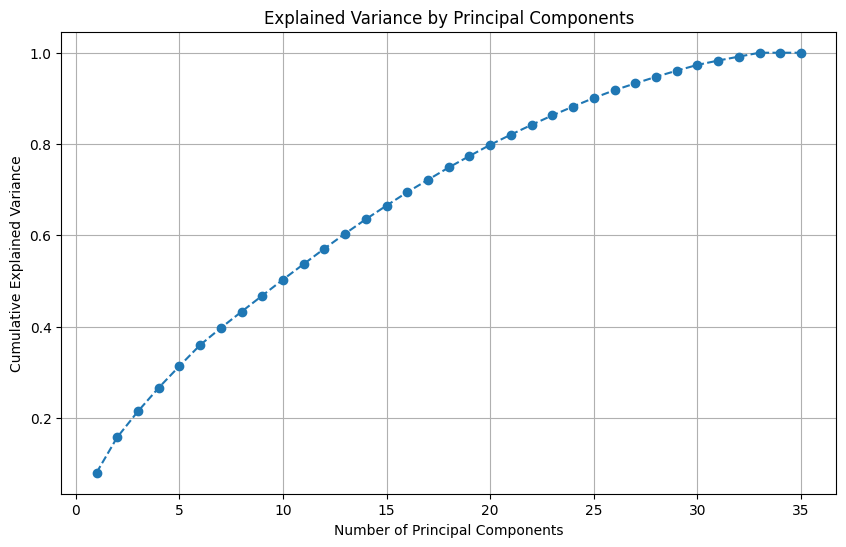

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Assign explanatory variables (features)
X = article_data_reduced.values  # Convert DataFrame to NumPy array
y = article_data_reduced['shares']  # Replace 'target' with the actual column name

# Split the data into training + testing subsets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=0)

# Standardizing the dataset (optional but recommended)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Apply PCA
pca = PCA()
pca.fit(X_train_scaled)

# Explained variance ratio
explained_variance_ratio = np.cumsum(pca.explained_variance_ratio_)

# Plot explained variance to determine the number of components
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o', linestyle='--')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by Principal Components')
plt.grid()
plt.show()

From the plot, we can say that the top 20 principal components explains 80% of the variance. If we increase the component their contribution marginally improves not contributing a significant value. Later to contrast we will also take top 15 as well as top 25.

In [ ]:
# Create PCA model (set number of components)
pca = PCA(n_components=20)

# Fit PCA on training data
pca.fit(X_train_scaled)

# Print explained variance ratio
print("Explained Variance Ratio:", pca.explained_variance_ratio_)


Explained Variance Ratio: [0.08020032 0.07771179 0.05674013 0.05155841 0.04746435 0.04622189
 0.03737987 0.03560264 0.03522474 0.0350822  0.03407497 0.03382421
 0.03279475 0.03156829 0.02990736 0.02931243 0.02713969 0.02694473
 0.02501682 0.02457178]


The explained variance is around 8% for the top component, whereas it is around 7%, 5% for two, 4% for two and the rest are around 3% and then gradually 2%.

We did not implement the strategy of adding or removing principal components one by one because the dataset is too large. Instead, we are using the plot above to conclude that it is satisfactory to use 20 principal components.

## 4. Regression Model Evaluation

In [ ]:
# load the LinearRegression() function from sklearn's 'linear_model' sub-library
from sklearn.linear_model import LinearRegression

# load the cross_val_score function from the sklearn.model_selection module
from sklearn.model_selection import cross_val_score


# Initialize the model
model = LinearRegression()

# Apply the results of PCA to the training data (Ensure PCA is already fitted)
X_t_train = pca.transform(X_train_scaled)

# Fit the Linear Regression model to the transformed training data
model.fit(X_t_train, y_train)

# Transform the test data using the same scaler and PCA
X_test_scaled = scaler.transform(X_test)  # Use transform instead of fit_transform
X_t_test = pca.transform(X_test_scaled)

# Evaluate the Linear Regression model using R^2 score
reg_score = model.score(X_t_test, y_test)

# Display model accuracy
print("R^2 Score on Test Data:", reg_score)

R^2 Score on Test Data: 0.9865920050333566


The R sqaured value of the regression model for test data is around 98%, which means the model is able to capture the relationship well.

In [ ]:
from sklearn.model_selection import cross_val_score
# Perform cross-validation and compute R^2 metrics
scores = cross_val_score(model, X_t_train, y_train, cv=5)

# Print out the R^2 metrics derived from the K-fold cross-validation
print("Cross-validation scores:", scores)

Cross-validation scores: [0.99700887 0.9982001  0.99471888 0.99039003 0.98931609]


Cross-validation looks consistent; the principal components are really helping the model capture the relationships and extract the most information from fewer features.

In [ ]:
# calculate the average R^2 across all 5 folds
np.mean(scores)

0.993926791854582

The average is around 99% for the cross validation R squared.

#### Top 25 Principal Components

In [ ]:
# Create PCA model (set number of components)
pca = PCA(n_components=25)

# Fit PCA on training data
pca.fit(X_train_scaled)

# Print explained variance ratio
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.08020032 0.07771179 0.05674013 0.05155841 0.04746435 0.04622189
 0.03737987 0.03560264 0.03522474 0.0350822  0.03407497 0.03382421
 0.03279475 0.03156829 0.02990736 0.02931243 0.02713969 0.02694473
 0.02501682 0.02457178 0.02231274 0.02145464 0.02065518 0.01939071
 0.01871496]


The explained variance is around 8% for the top component, whereas it is around 7%, 5% for two, 4% for two and the rest are around 3% and then gradually 2%. And then the new components as compared to the previous one have 2% and 1% for last two.

#### Regression model Analysis

In [ ]:
# load the LinearRegression() function from sklearn's 'linear_model' sub-library
from sklearn.linear_model import LinearRegression

# load the cross_val_score function from the sklearn.model_selection module
from sklearn.model_selection import cross_val_score


# Initialize the model
model = LinearRegression()

# Apply the results of PCA to the training data (Ensure PCA is already fitted)
X_t_train = pca.transform(X_train_scaled)

# Fit the Linear Regression model to the transformed training data
model.fit(X_t_train, y_train)

# Transform the test data using the same scaler and PCA
X_test_scaled = scaler.transform(X_test)  # Use transform instead of fit_transform
X_t_test = pca.transform(X_test_scaled)

# Evaluate the Linear Regression model using R^2 score
reg_score = model.score(X_t_test, y_test)

# Display model accuracy
print("R^2 Score on Test Data:", reg_score)

R^2 Score on Test Data: 0.9915199948346768


A better R squared score, jumping up from around 98% to around 99%, which is a small jump as compared to the amount of extra columns (5) we introduced.

In [ ]:
from sklearn.model_selection import cross_val_score
# Perform cross-validation and compute R^2 metrics
scores = cross_val_score(model, X_t_train, y_train, cv=5)

# Print out the R^2 metrics derived from the K-fold cross-validation
print("Cross-validation scores:", scores)

Cross-validation scores: [0.99954575 0.99970922 0.99916336 0.99873191 0.99820535]


There is not much variation in the R sqaured for any of the fold's R squared. That means the principle components.

In [ ]:
# calculate the average R^2 across all 5 folds
np.mean(scores)

0.9990711197663973

The average R squared value for 5 fold cross validation is around 99.9%.

#### Top 15 Principal Components

In [ ]:
# Create PCA model (set number of components)
pca = PCA(n_components=15)

# Fit PCA on training data
pca.fit(X_train_scaled)

# Print explained variance ratio
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.08020032 0.07771179 0.05674013 0.05155841 0.04746435 0.04622189
 0.03737987 0.03560264 0.03522474 0.0350822  0.03407497 0.03382421
 0.03279475 0.03156829 0.02990736]


The explained variance is around 8% for the top component, whereas it is around 7%, 5% for two, 4% for two and the rest are around 3% and then gradually to the last value of 2%.

#### Regression model Analysis

In [ ]:
# load the LinearRegression() function from sklearn's 'linear_model' sub-library
from sklearn.linear_model import LinearRegression

# load the cross_val_score function from the sklearn.model_selection module
from sklearn.model_selection import cross_val_score


# Initialize the model
model = LinearRegression()

# Apply the results of PCA to the training data (Ensure PCA is already fitted)
X_t_train = pca.transform(X_train_scaled)

# Fit the Linear Regression model to the transformed training data
model.fit(X_t_train, y_train)

# Transform the test data using the same scaler and PCA
X_test_scaled = scaler.transform(X_test)  # Use transform instead of fit_transform
X_t_test = pca.transform(X_test_scaled)

# Evaluate the Linear Regression model using R^2 score
reg_score = model.score(X_t_test, y_test)

# Display model accuracy
print("R^2 Score on Test Data:", reg_score)

R^2 Score on Test Data: -5.609492276107029


Here, the value of R squared is negative, that means a horizontal line explains the data better than our model. Therefore, the Principal Components we removed ended up affecting the ability of the model to capture relations effectively. Reducing the components ended up reducing the information significant for effective model convergence.


Reference: https://stats.stackexchange.com/questions/183265/what-does-negative-r-squared-mean

In [ ]:
from sklearn.model_selection import cross_val_score
# Perform cross-validation and compute R^2 metrics
scores = cross_val_score(model, X_t_train, y_train, cv=5)

# Print out the R^2 metrics derived from the K-fold cross-validation
print("Cross-validation scores:", scores)

Cross-validation scores: [ 0.38821068  0.39611023  0.25794422 -0.08685982 -0.20859801]


Similar effect of reducing the components can be seen in the cross validation scores. Some scores are close to 0, meaning the model explains the data as well as a horizontal line, while some are below 0.

In [ ]:
# calculate the average R^2 across all 5 folds
np.mean(scores)

0.14936146024480887

As we can see with 15 Principal Components the model performance drops as it does not explain more than 62% variability in the data from the curve we plotted for the components and Cumulative explainability of variance. Whereas with 20 or 25 even better, the model trained on these performs really well, as model is able to capture most of the variability present in terms of the Principal Components.

## 5. Conclusions



We analyzed a dataset of 39,643 news articles with 61 features to predict article shares. After cleaning and performing extensive EDA, we reduced feature redundancy using correlation analysis and applied PCA for dimensionality reduction. Using 20–25 principal components, our Linear Regression model achieved high accuracy (R² ~98%-99%), whereas using only 15 components led to poor performance. This study demonstrates that effective feature selection and PCA can simplify high-dimensional data while retaining predictive power.

